# Import

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

import joblib
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from physics.Iso_data_handler import Iso_data_handler
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [4]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_B/final_models/"
path_to_predictions = pre_path + "predictions/model_B/final_models/"
path_to_models = 'model/final_models/model_B/PARSEC/'
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]

# Data preparation

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

In [7]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'metallicity', 'Mass'], 
                               y_cols=['logTe', 'logg', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the logTe parameter : 3.3621 - 4.5177
Median value in train data for the logTe parameter: 3.721
Mean value in train data for the logTe parameter: 3.777965141417156

Range in train data for the logg parameter : -0.384 - 5.345
Median value in train data for the logg parameter: 2.486
Mean value in train data for the logg parameter: 2.761182341921151

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the logTe parameter : 3.3622 - 4.5177
Median value in test data for the logTe parameter: 3.721
Mean value in test data for the logTe parameter: 3.777738115487914

Range in test data for the logg parameter : -0.347 - 5.345
Median value in test data for the logg parameter: 2.486
Mean value in test data for the logg parameter: 2.75

In [8]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")
X_train_power, X_ivs_power = Data_preparator.scale_data(X_train, X_ivs, "power")

print(X_train_quantile.shape, X_ivs_quantile.shape)
print(X_train_power.shape, X_ivs_power.shape)

(241272, 3) (80424, 3)
(241272, 3) (80424, 3)


# Getting the final evaluations

## Random forest

In [11]:
tag = "scale_quantile"


scale_quantile train data :
Training the model...
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.9808891844573724
  RMSE :  0.03759208496129535
  MAE :  0.009420756929628798
  MedAE :  0.0012138156790779675
  CORR :  0.9904855360225372
  MAX_ER :  0.7923797303471045
  Percentiles : 
    75th percentile :  0.005375843542065106
    90th percentile :  0.019339869327994294
    95th percentile :  0.039457130817337135
    99th percentile :  0.12555491225632445

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.9138574715250227
  RMSE :  0.051414304603705316
  MAE :  0.032059315712959814
  MedAE :  0.017770225220683056
  CORR :  0.9596471323005165
  MAX_ER :  0.5575481708898504
  Percentiles : 
    75th percentile :  0.043742736285176775
    90th percentile :  0.07909890004824259
    95th percentile :  0.10647404110607067
    99th percentile : 

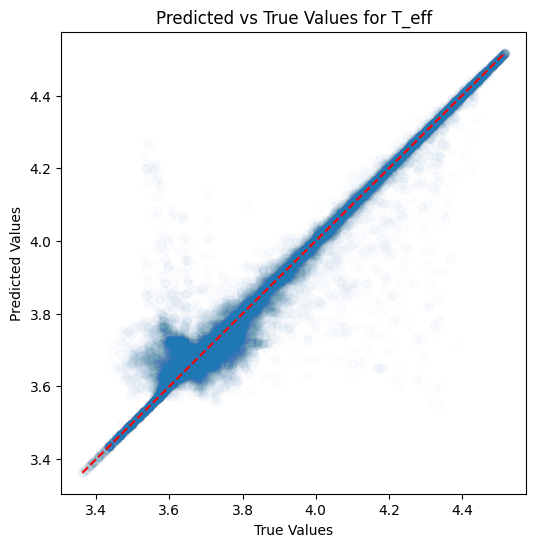

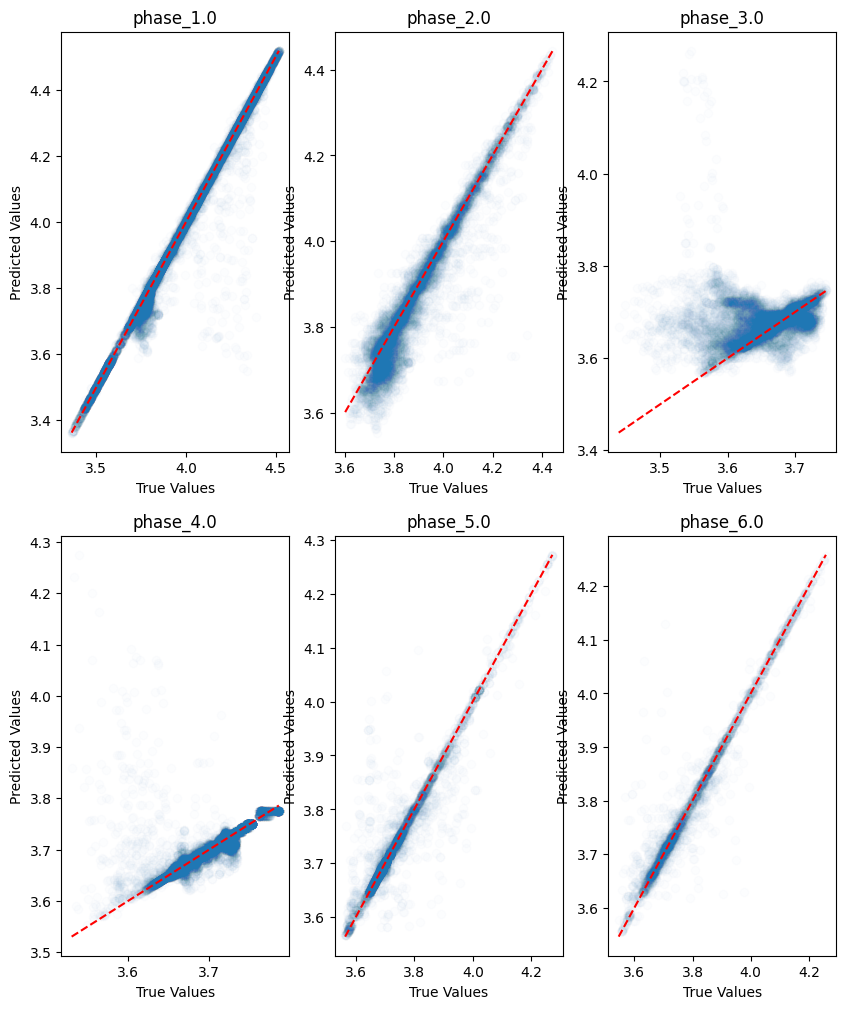

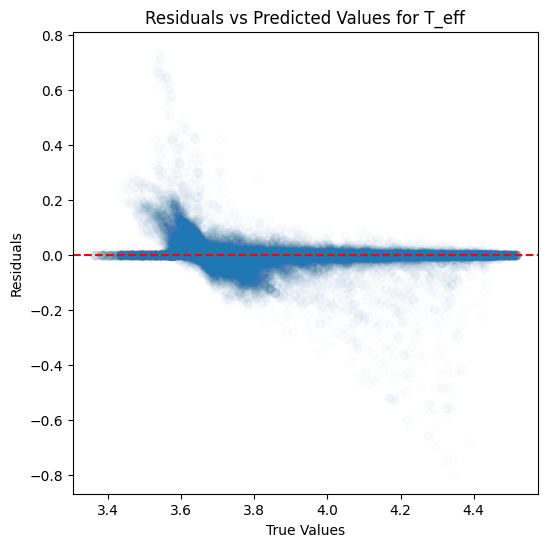

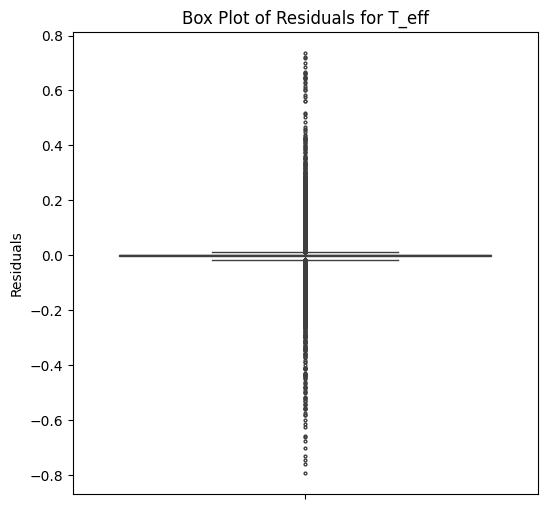

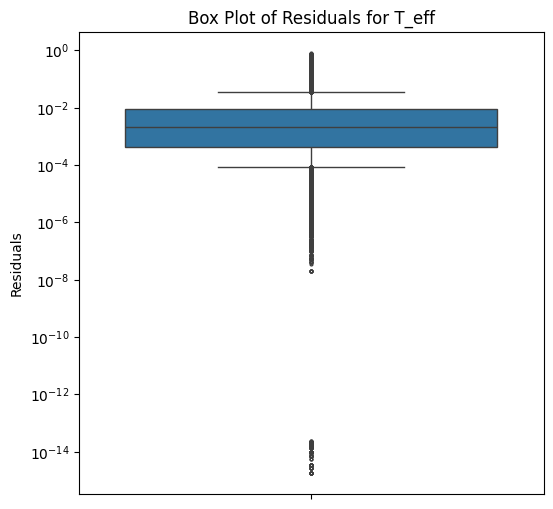

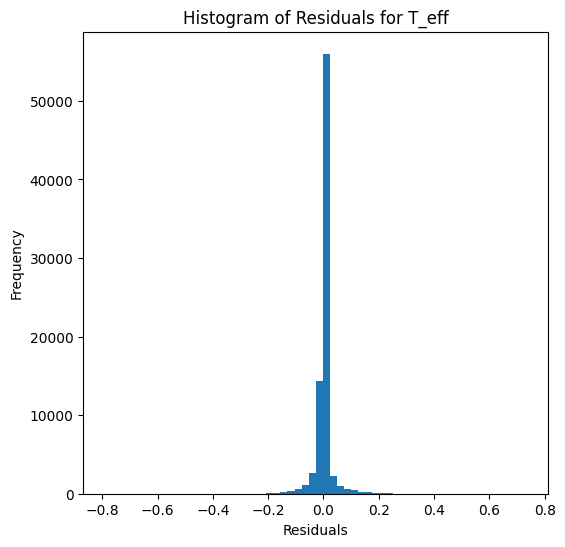

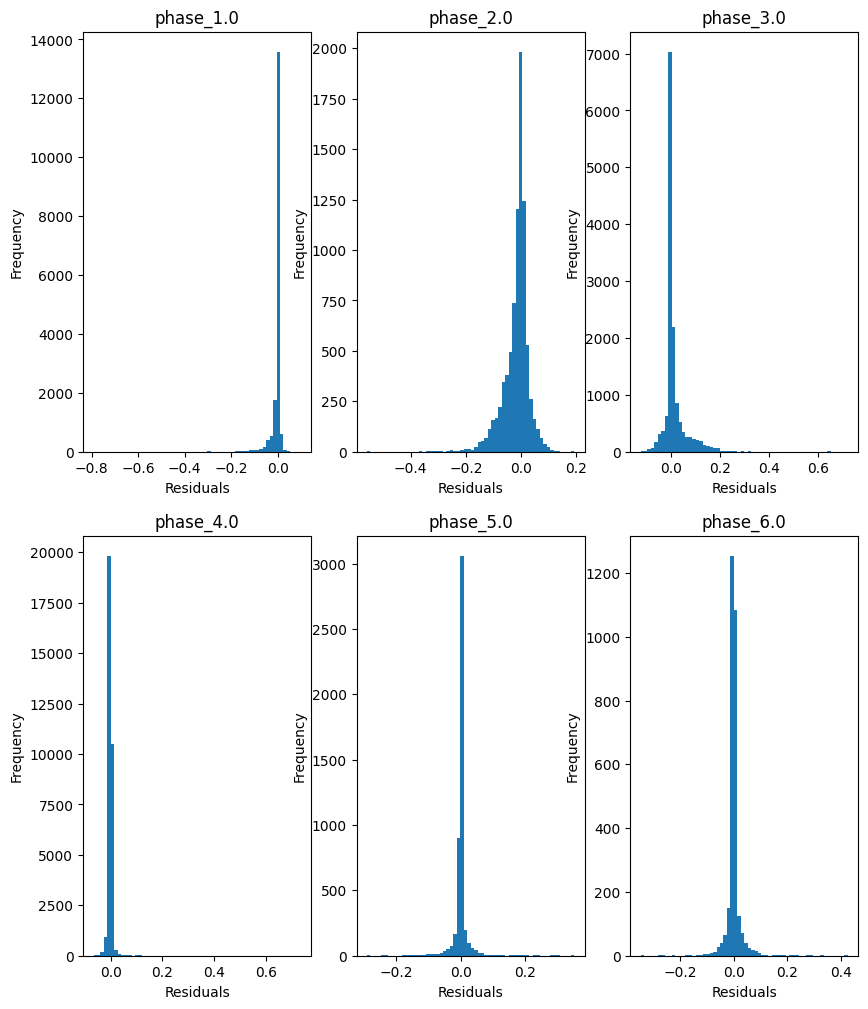

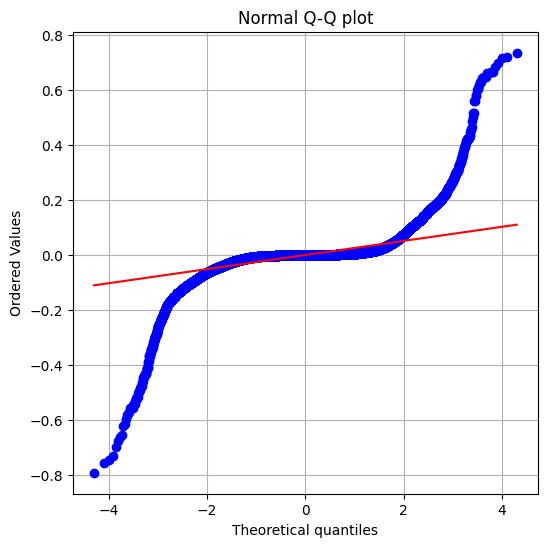

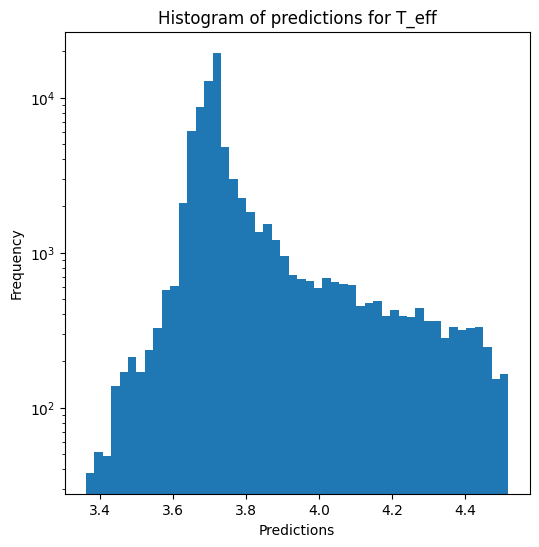

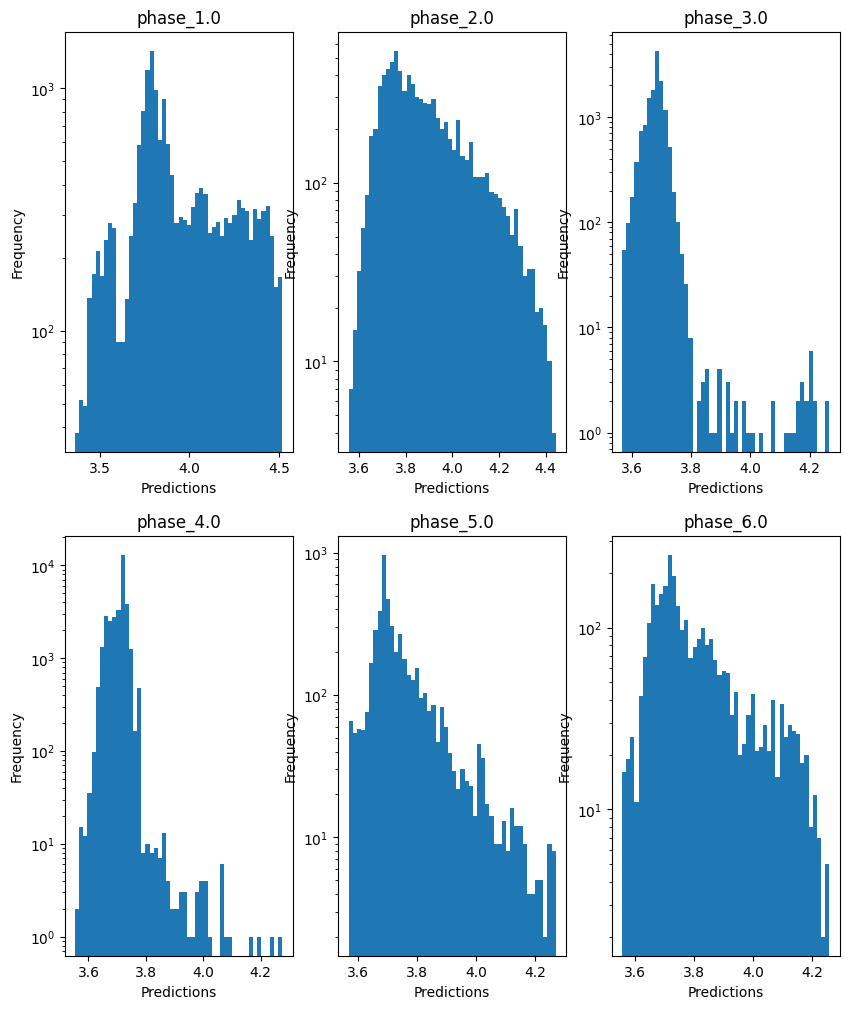


log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.29290872220492015
  RMSE :  0.29791079383054253
  MAE :  0.08449649950177231
  MedAE :  0.004331732304050373
  CORR :  0.8065257351434265
  MAX_ER :  3.491773363993923
  Percentiles : 
    75th percentile :  0.020161891786393826
    90th percentile :  0.1629853393341716
    95th percentile :  0.5474902834164651
    99th percentile :  1.6787769525686123

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.63753718958849
  RMSE :  0.5291536331229766
  MAE :  0.2724310428807879
  MedAE :  0.07193735720651762
  CORR :  0.8124687270771878
  MAX_ER :  3.021992637633252
  Percentiles : 
    75th percentile :  0.23666620654871928
    90th percentile :  0.9970000699179437
    95th percentile :  1.3425172377216246
    99th percentile :  1.9427826452257888

log_g results for the phase category with a value of 3.0
  value range :  -0.347 - 3.787
  RVE :

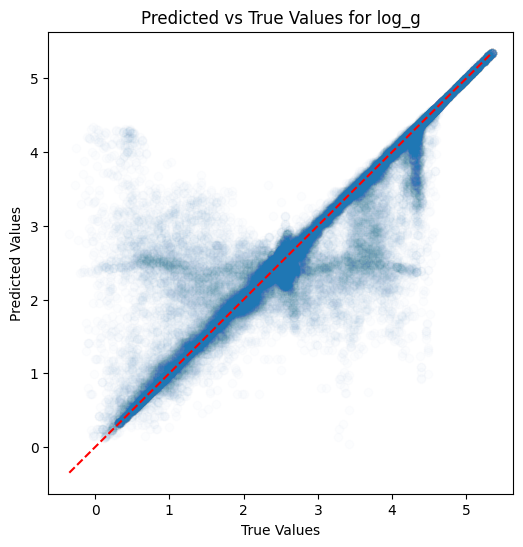

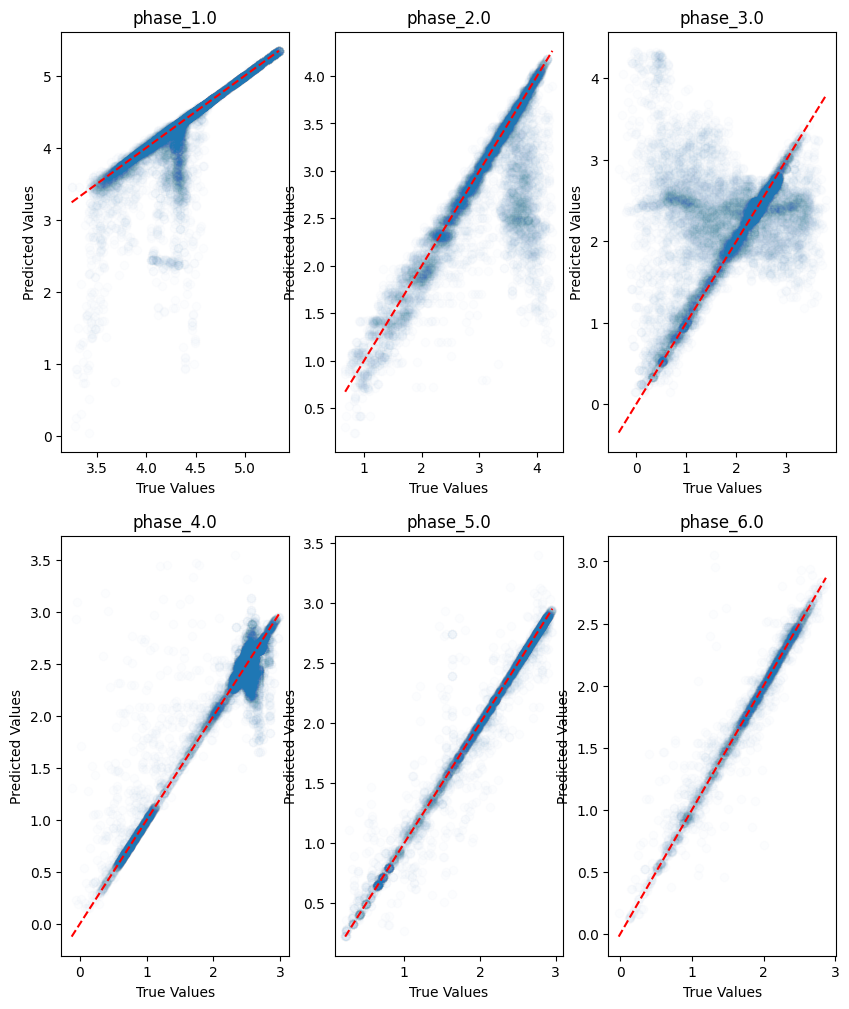

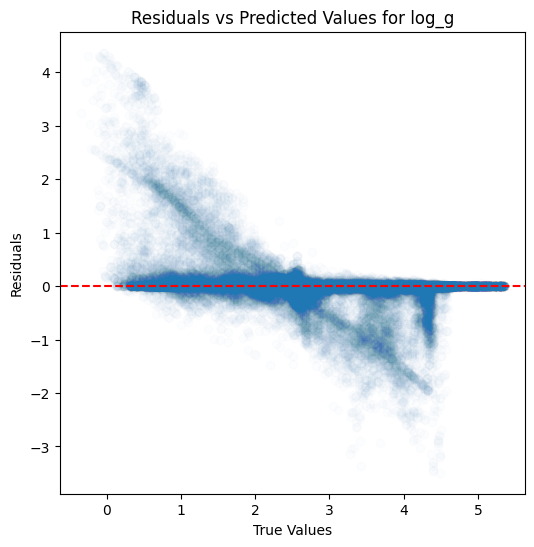

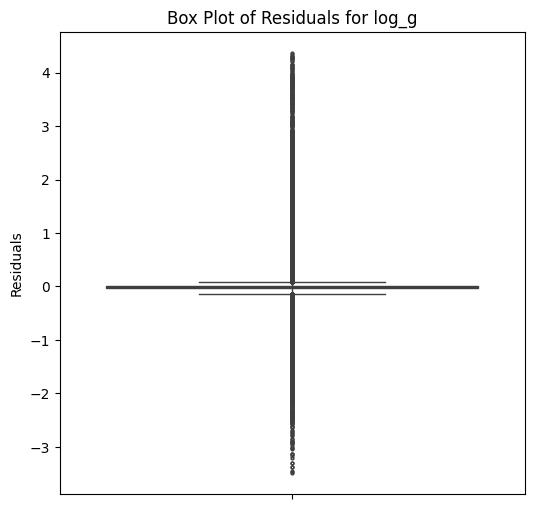

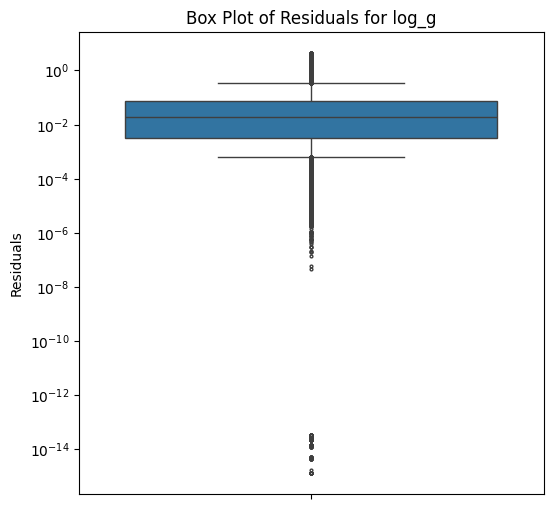

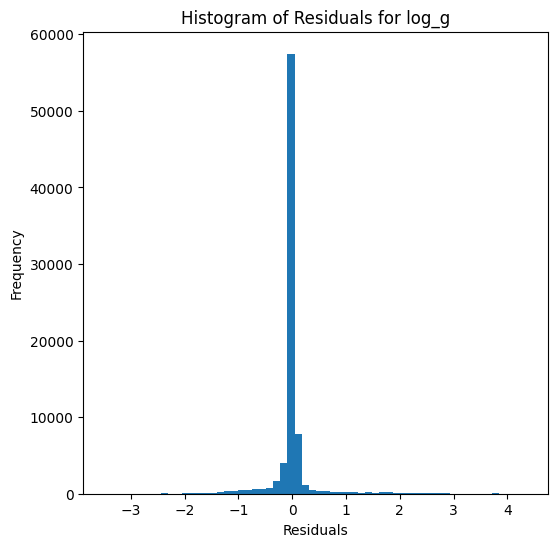

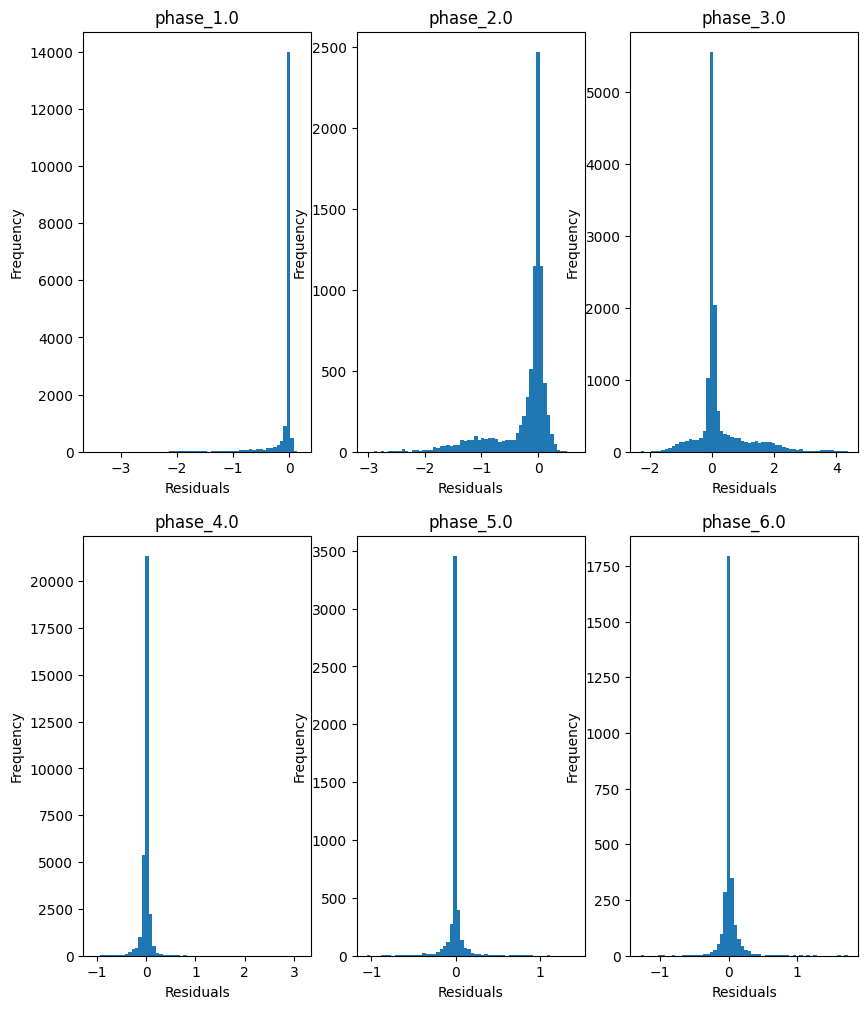

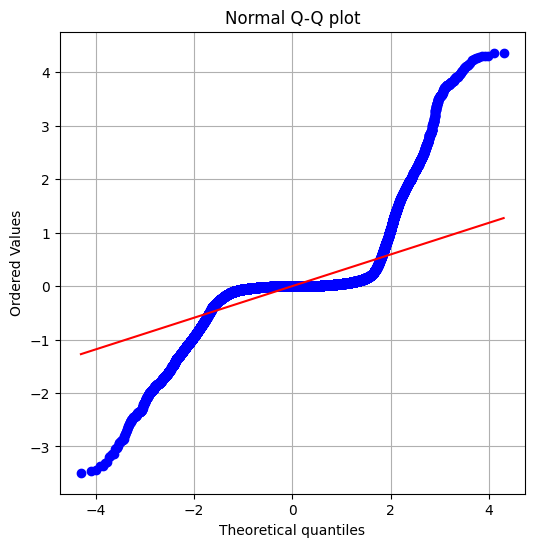

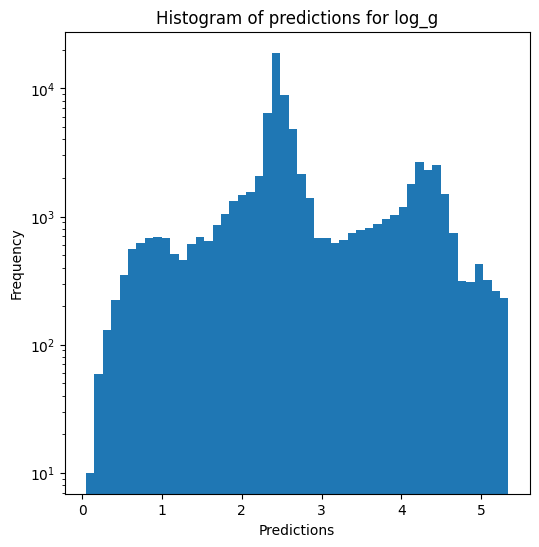

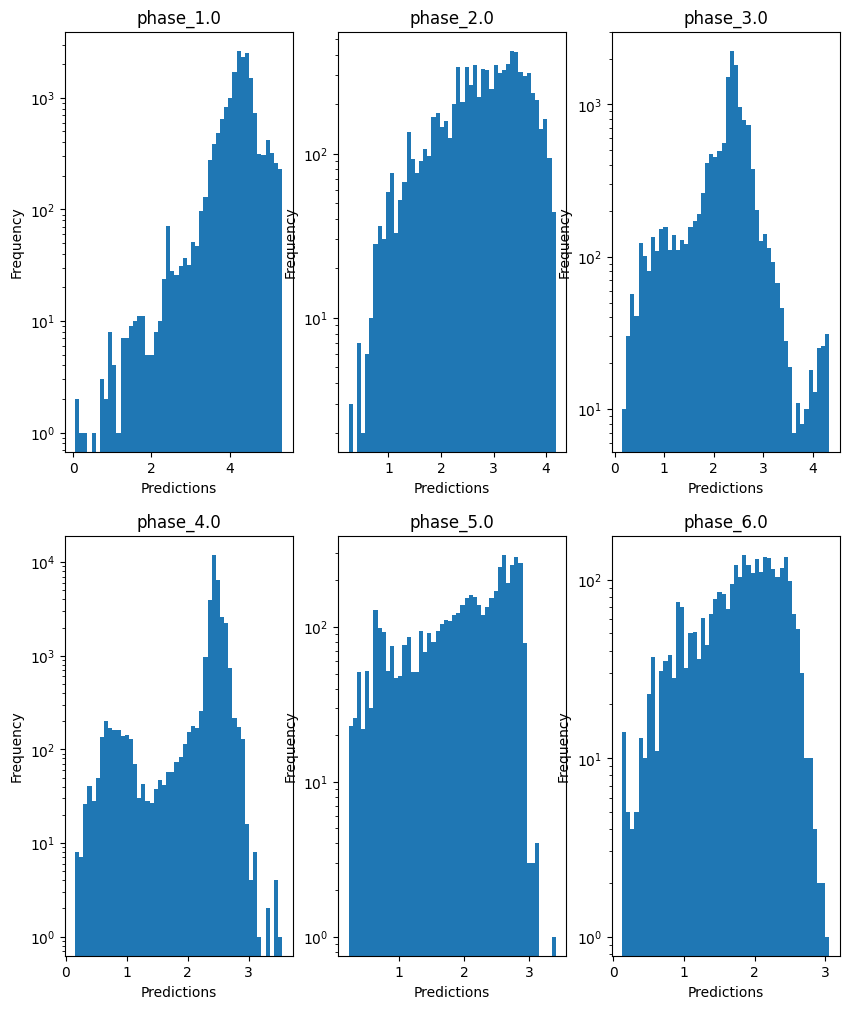

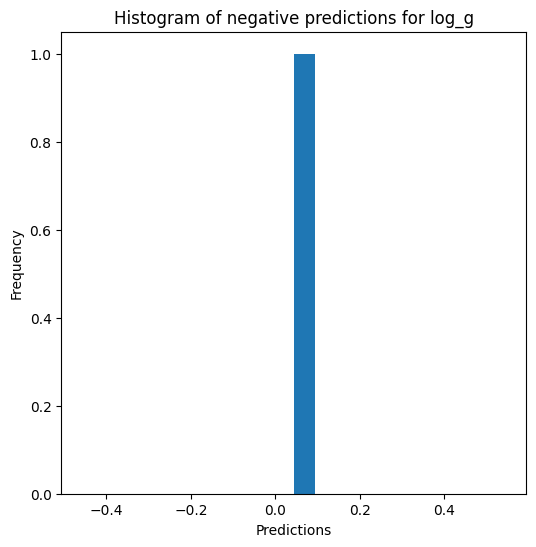


radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.8466034601998274
  RMSE :  0.14957865554739905
  MAE :  0.043400135059162515
  MedAE :  0.002797717109805531
  CORR :  0.9332432727250753
  MAX_ER :  1.7457947290301834
  Percentiles : 
    75th percentile :  0.012386994301304459
    90th percentile :  0.08297183016818088
    95th percentile :  0.27417759150710896
    99th percentile :  0.8384918436208302

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.8025090885125871
  RMSE :  0.264588371468658
  MAE :  0.13625495511847507
  MedAE :  0.036033263138516236
  CORR :  0.8958842388380948
  MAX_ER :  1.5097529576324848
  Percentiles : 
    75th percentile :  0.11833985144316062
    90th percentile :  0.4986993771911672
    95th percentile :  0.6713414284996011
    99th percentile :  0.9714367286005472

radius results for the phase categor

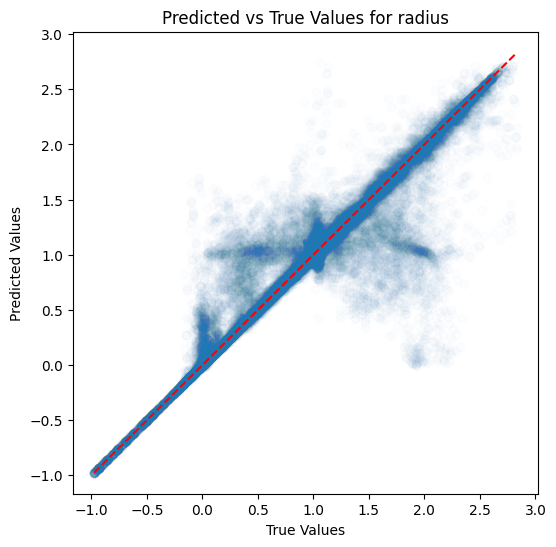

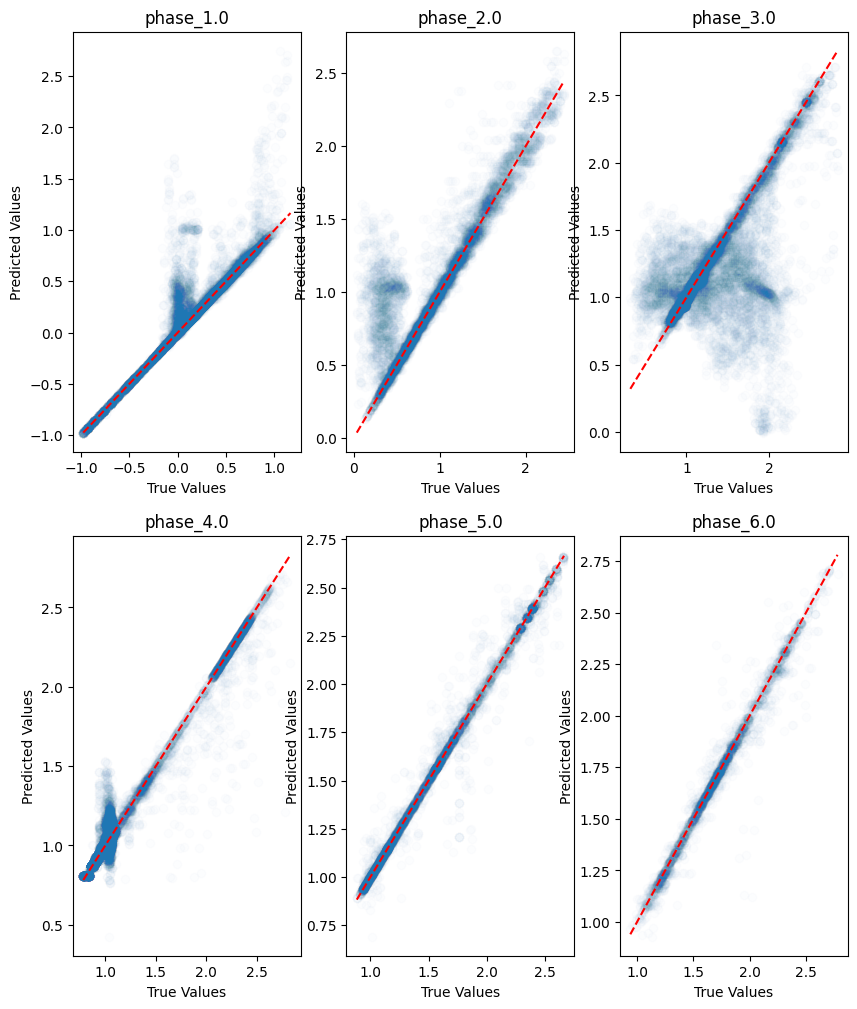

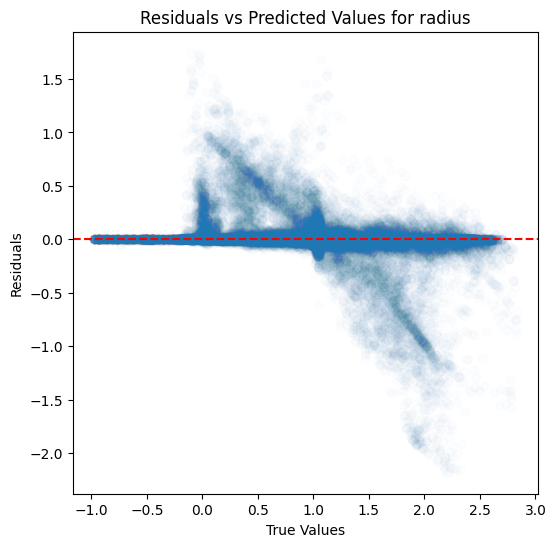

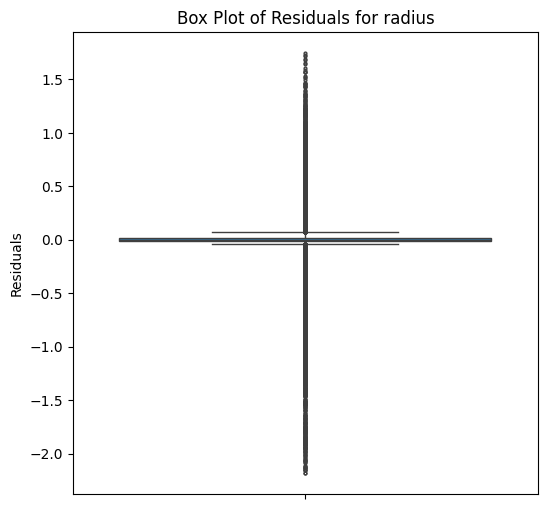

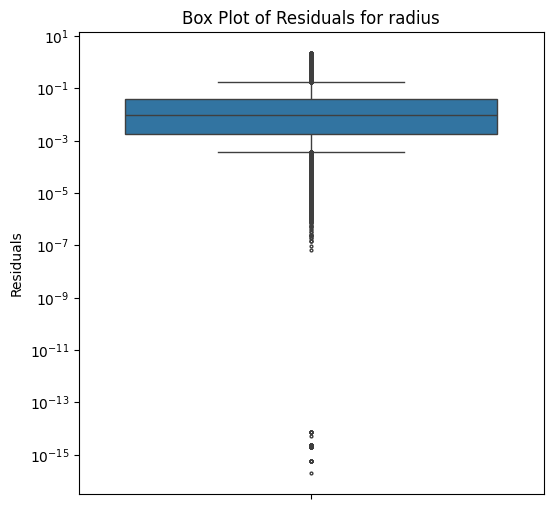

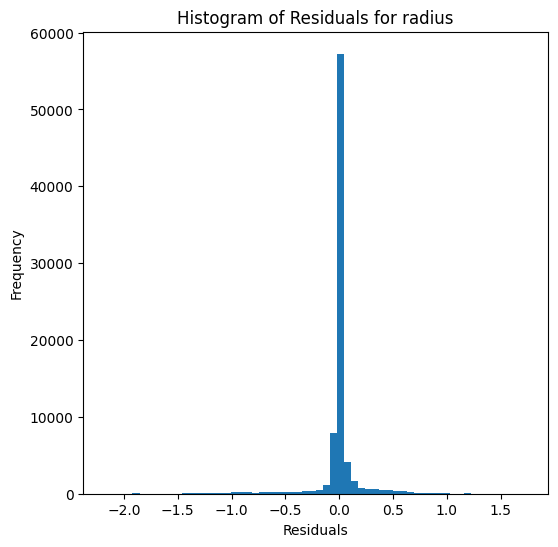

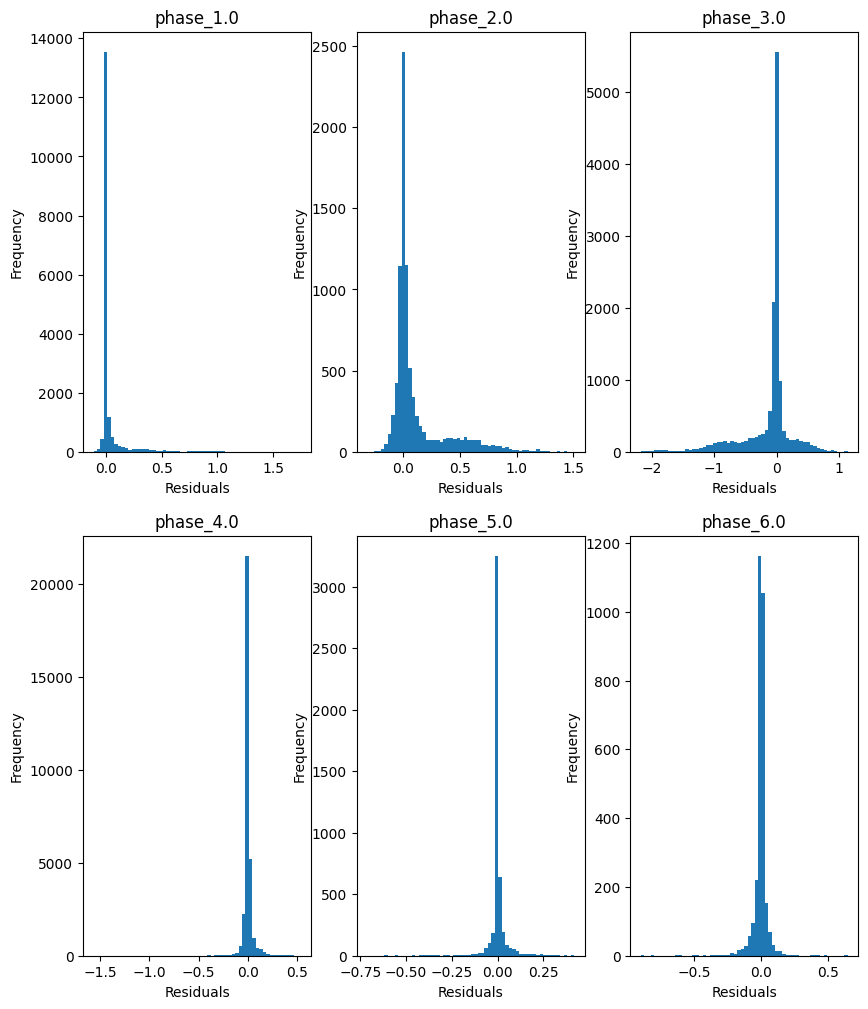

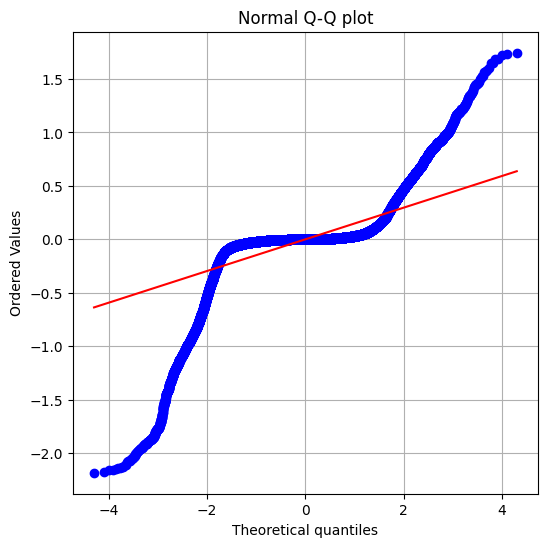

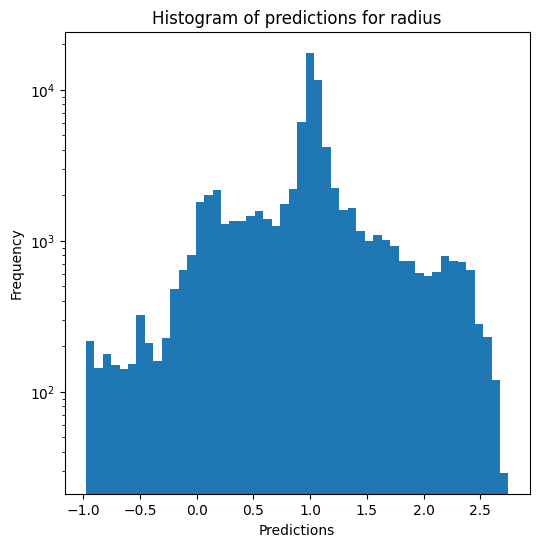

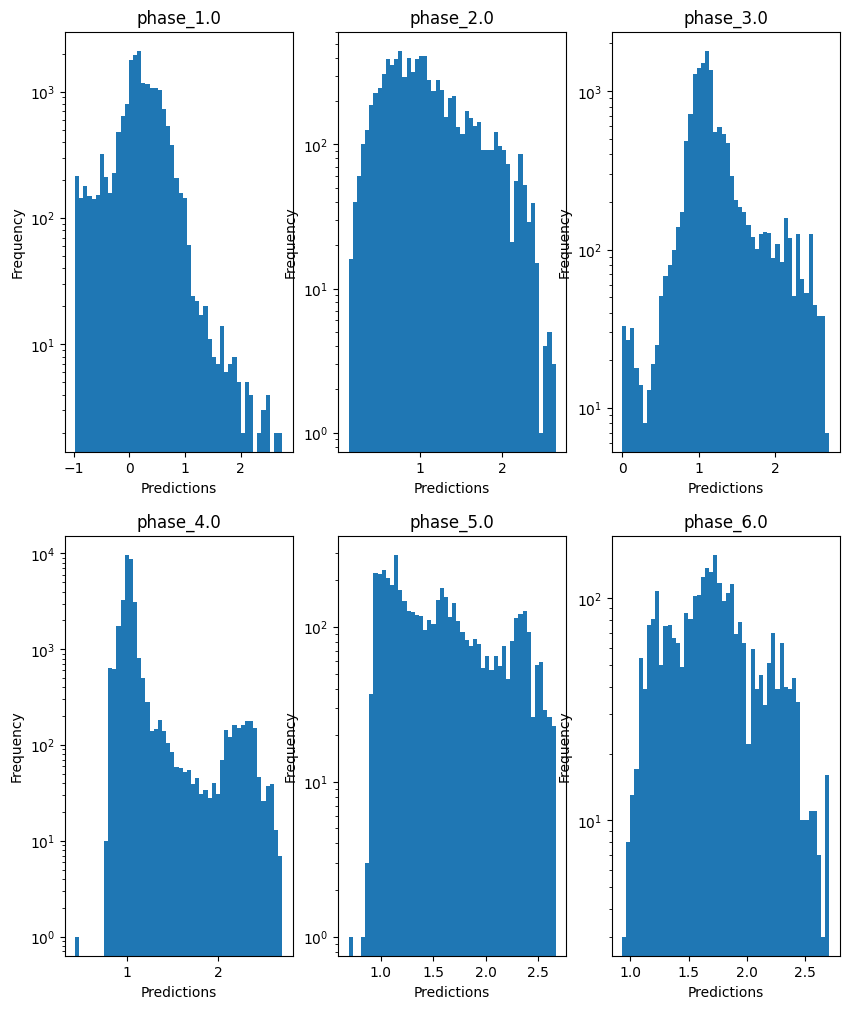

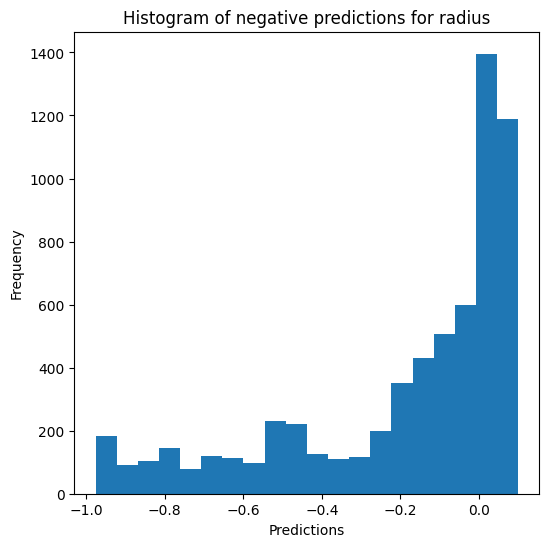

Saving predictions and results...


In [12]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 3, 'min_samples_split': 10, 'max_features': None, 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_RF)

## KNN

In [13]:
tag = "scale_power"

../../../../../../results/model_B/final_models/

scale_power train data :
Training the model...
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.9750459994861356
  RMSE :  0.04289132785316836
  MAE :  0.012040957725615312
  MedAE :  0.0024300000000003763
  CORR :  0.9875238921270711
  MAX_ER :  0.7854899999999998
  Percentiles : 
    75th percentile :  0.008510000000000795
    90th percentile :  0.024119999999999874
    95th percentile :  0.040223999999999815
    99th percentile :  0.16453770000000567

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.9111531940454642
  RMSE :  0.061104242948301975
  MAE :  0.04289799274344569
  MedAE :  0.03120999999999996
  CORR :  0.9555937052664674
  MAX_ER :  0.5678899999999998
  Percentiles : 
    75th percentile :  0.05915500000000007
    90th percentile :  0.09584400000000053
    95th percentile :  

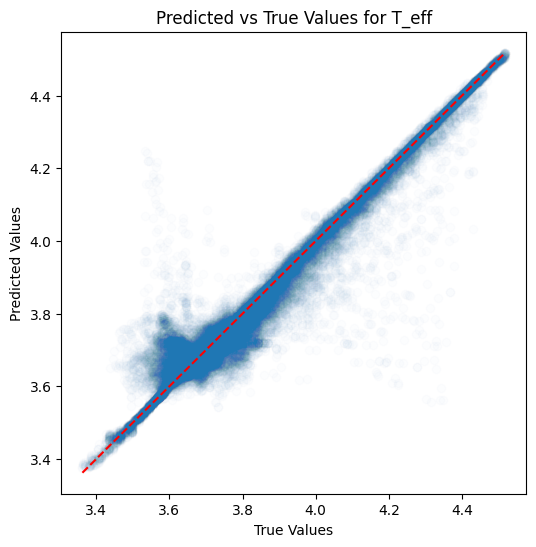

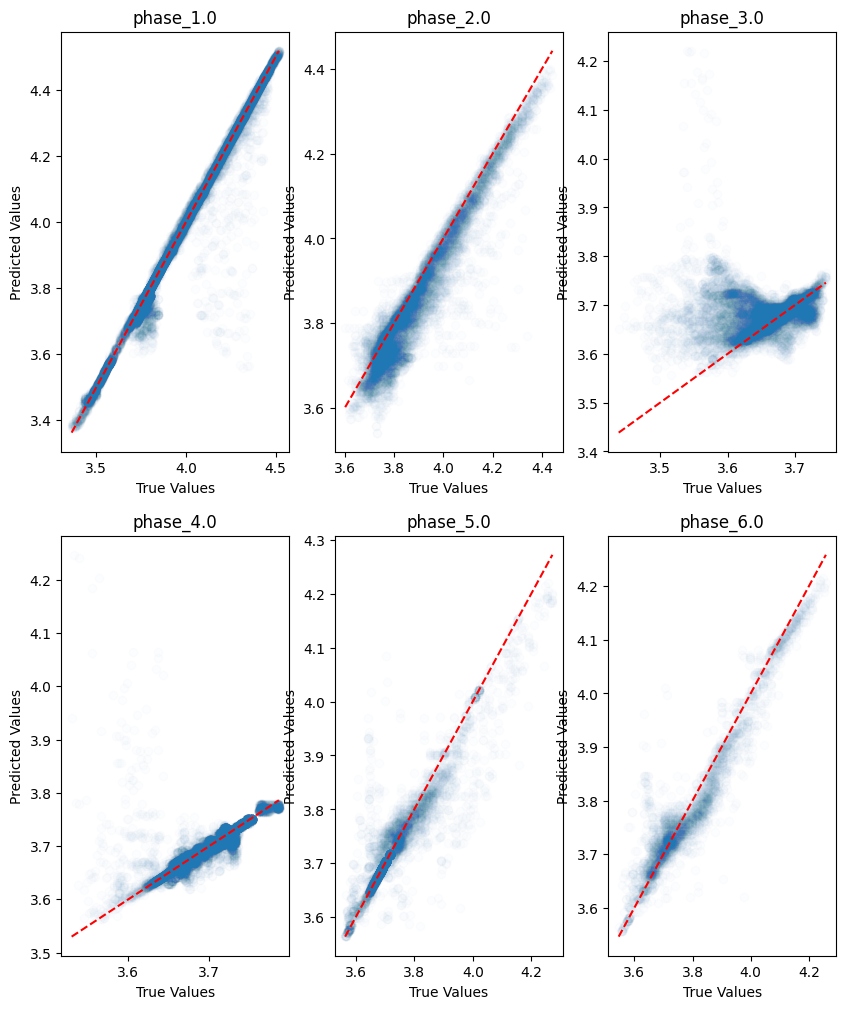

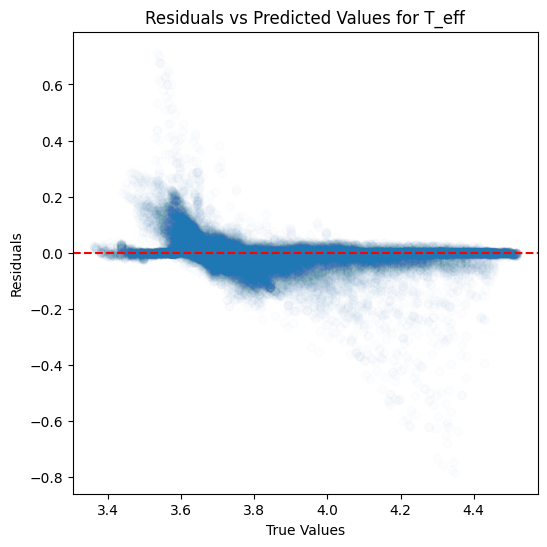

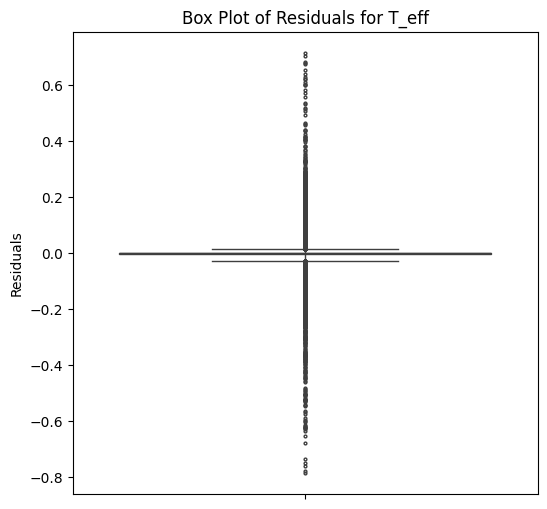

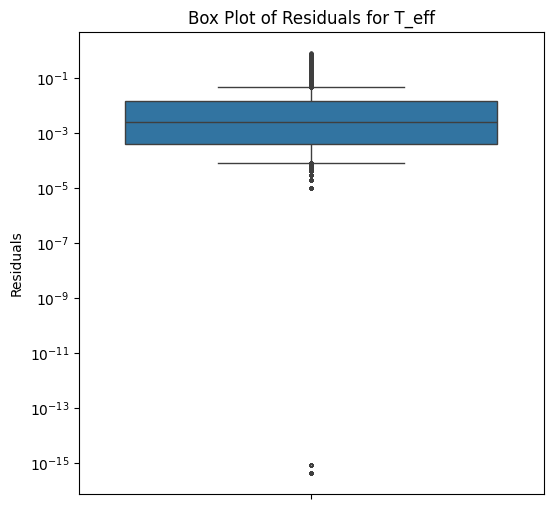

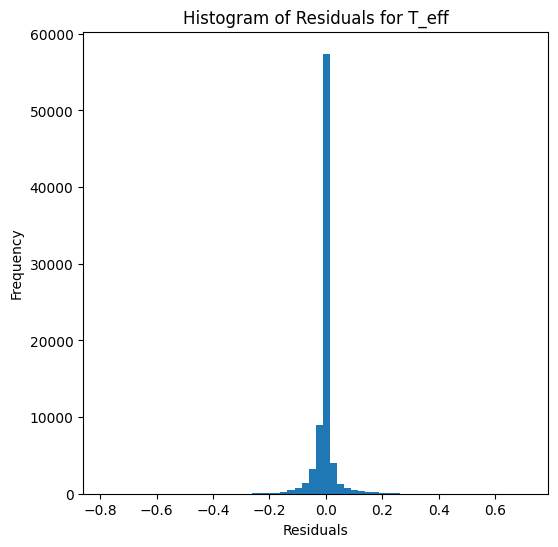

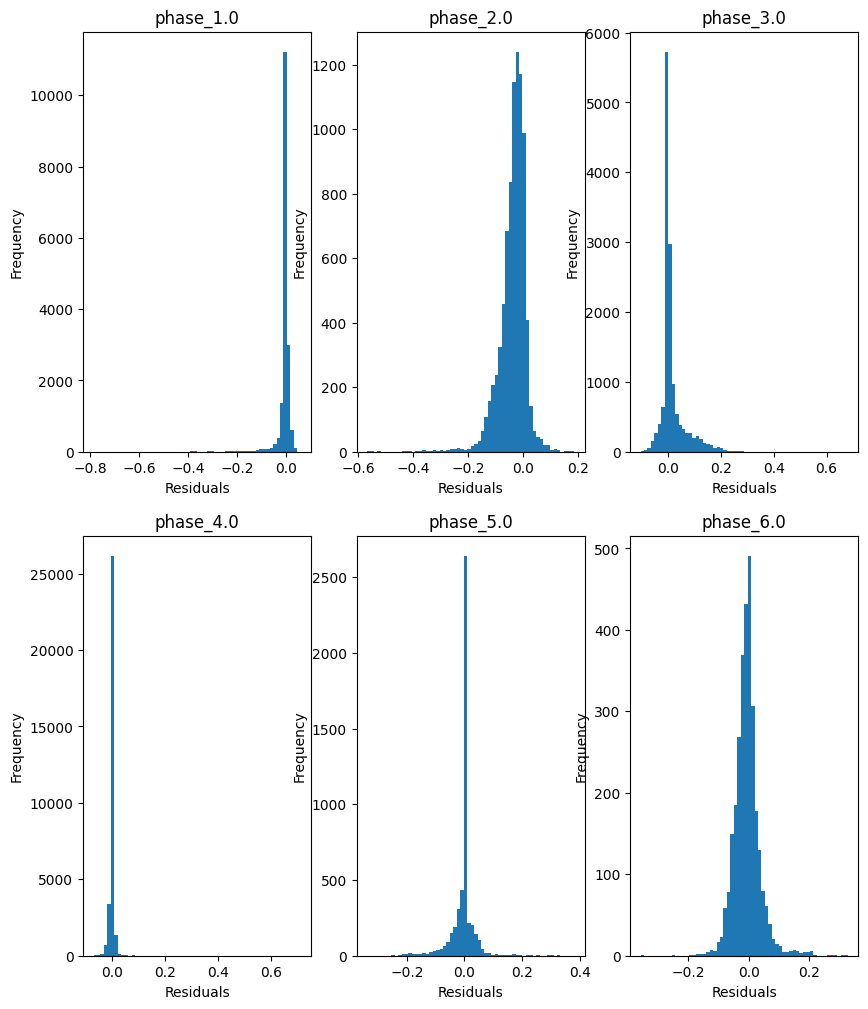

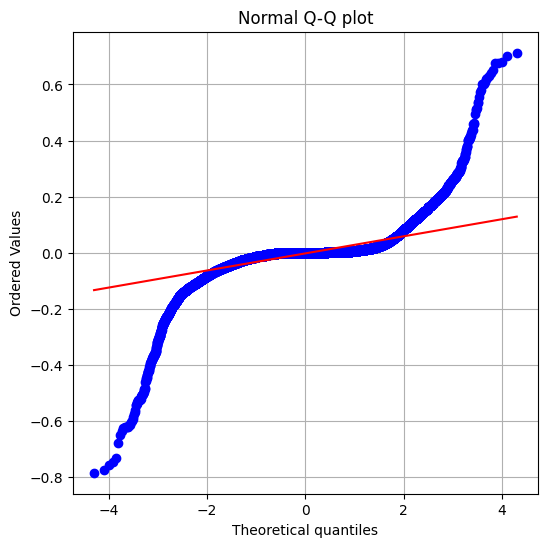

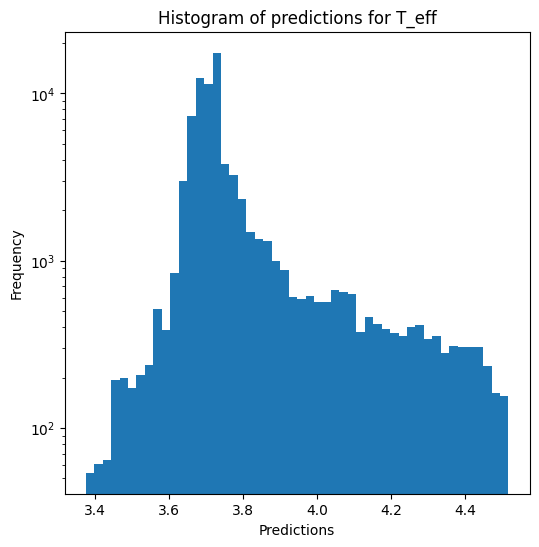

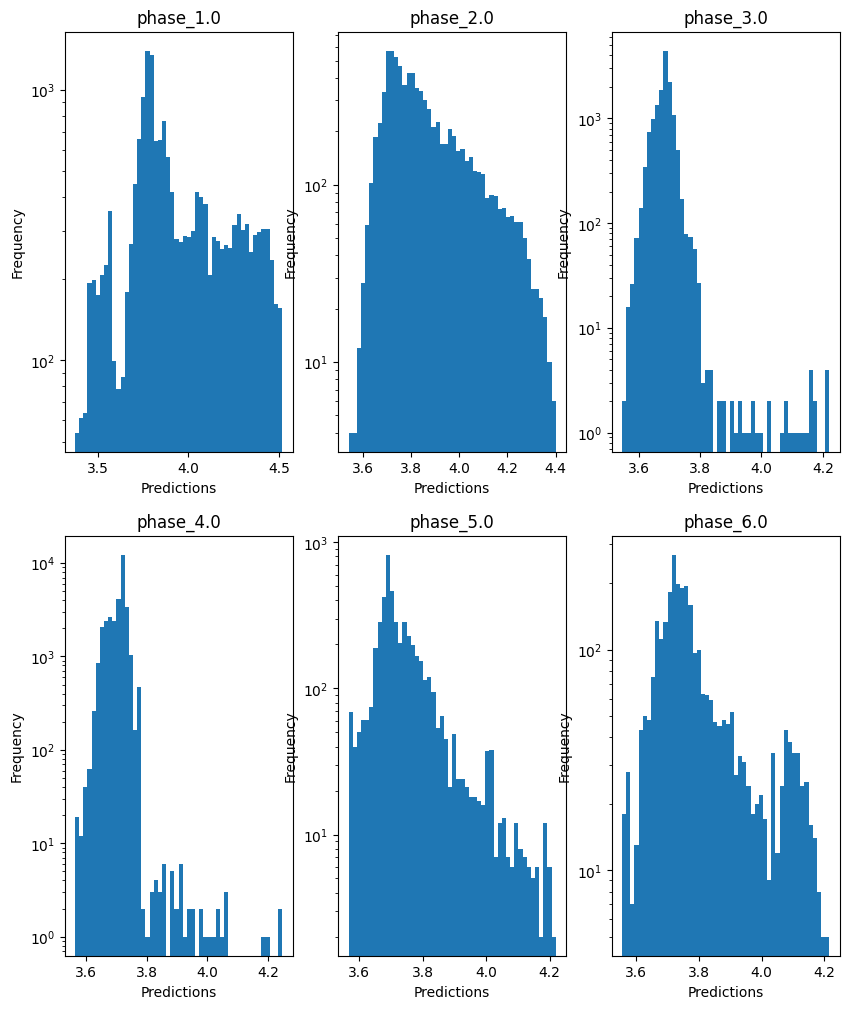


log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.04990062231013781
  RMSE :  0.3476110709665336
  MAE :  0.10460587397447586
  MedAE :  0.006700000000000372
  CORR :  0.7696123004008696
  MAX_ER :  3.4656999999999996
  Percentiles : 
    75th percentile :  0.02880000000000038
    90th percentile :  0.37380000000000013
    95th percentile :  0.44438000000000066
    99th percentile :  1.9206800000000033

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.6484552651932723
  RMSE :  0.5647100951877659
  MAE :  0.33060972612359557
  MedAE :  0.13465000000000016
  CORR :  0.8178076984433407
  MAX_ER :  3.2024999999999997
  Percentiles : 
    75th percentile :  0.3561249999999997
    90th percentile :  1.02955
    95th percentile :  1.3183199999999993
    99th percentile :  1.9984129999999998

log_g results for the phase category with a value of 3.0
  value range :  -0.347 - 3.787
  RVE :  -0.04

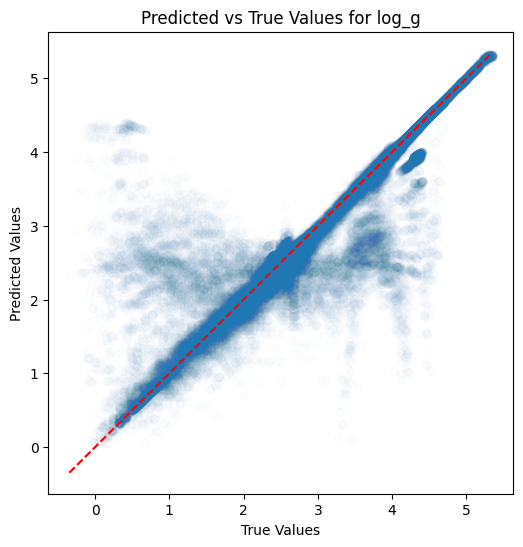

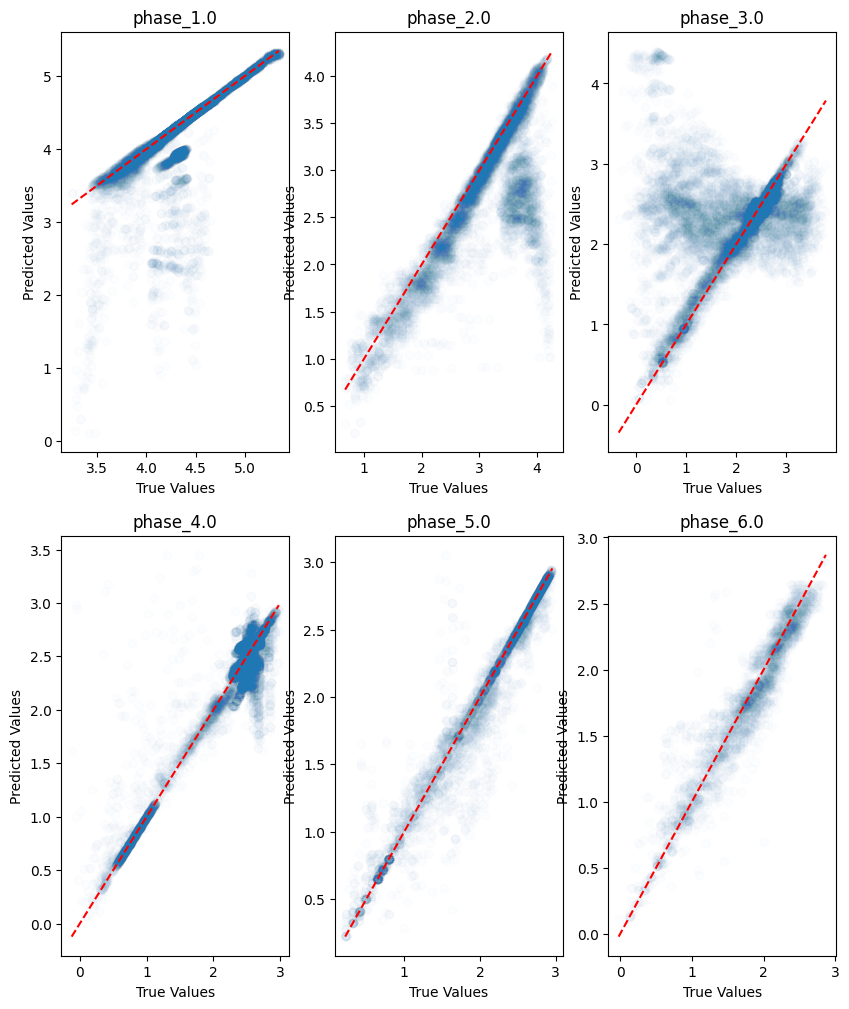

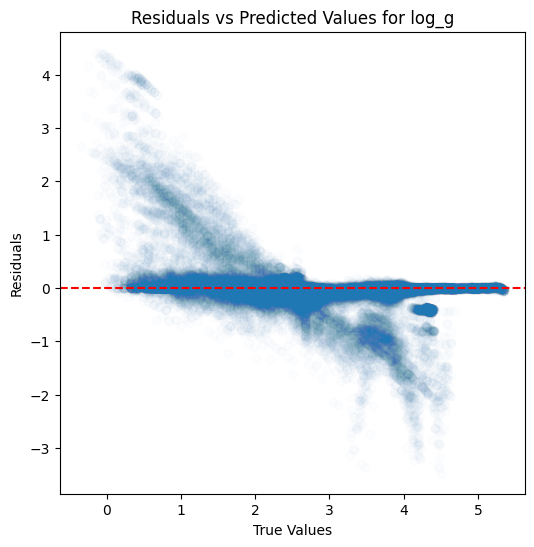

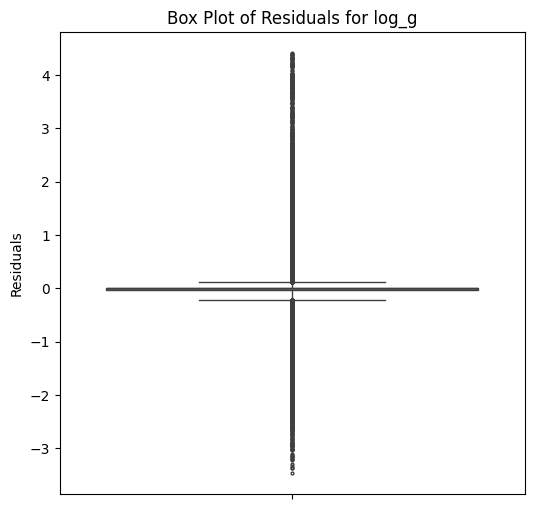

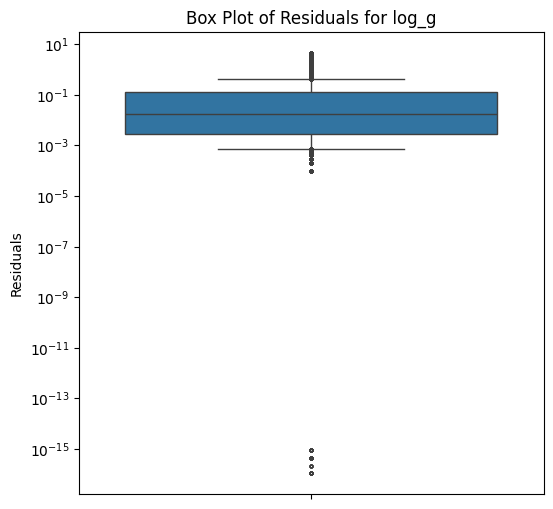

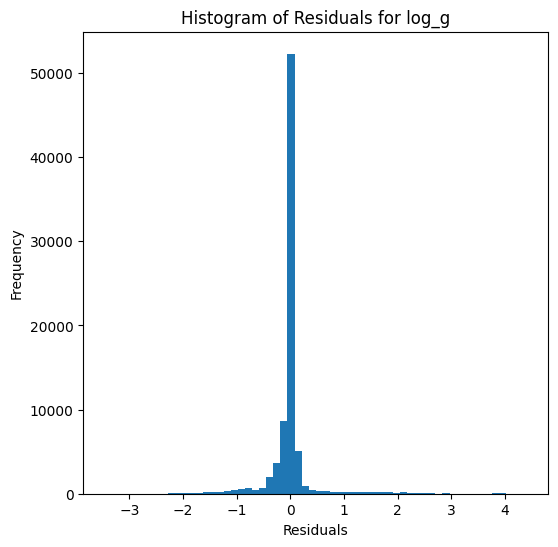

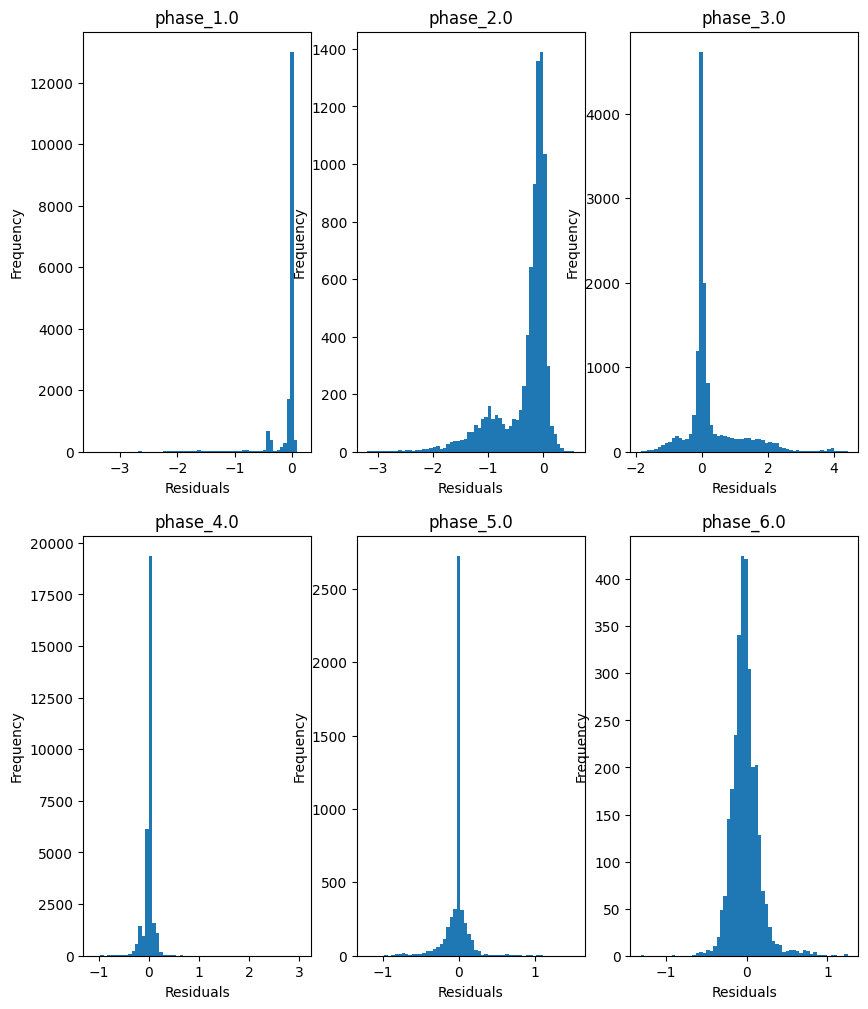

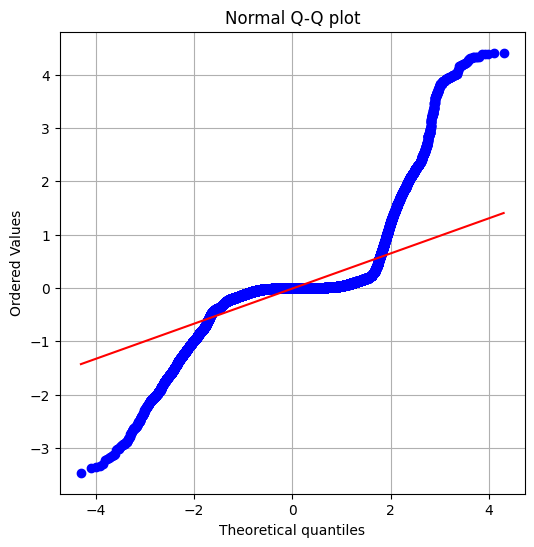

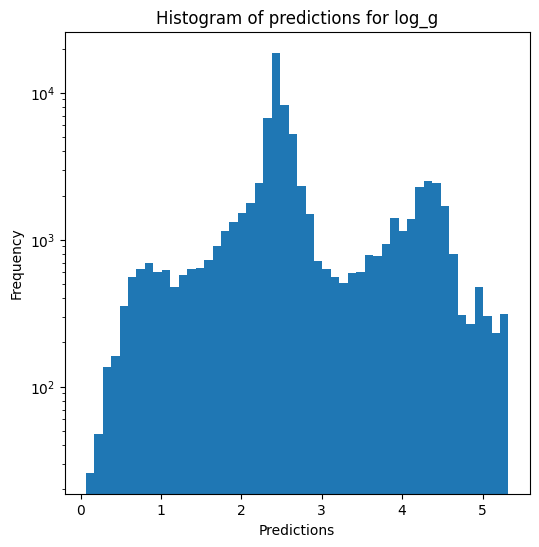

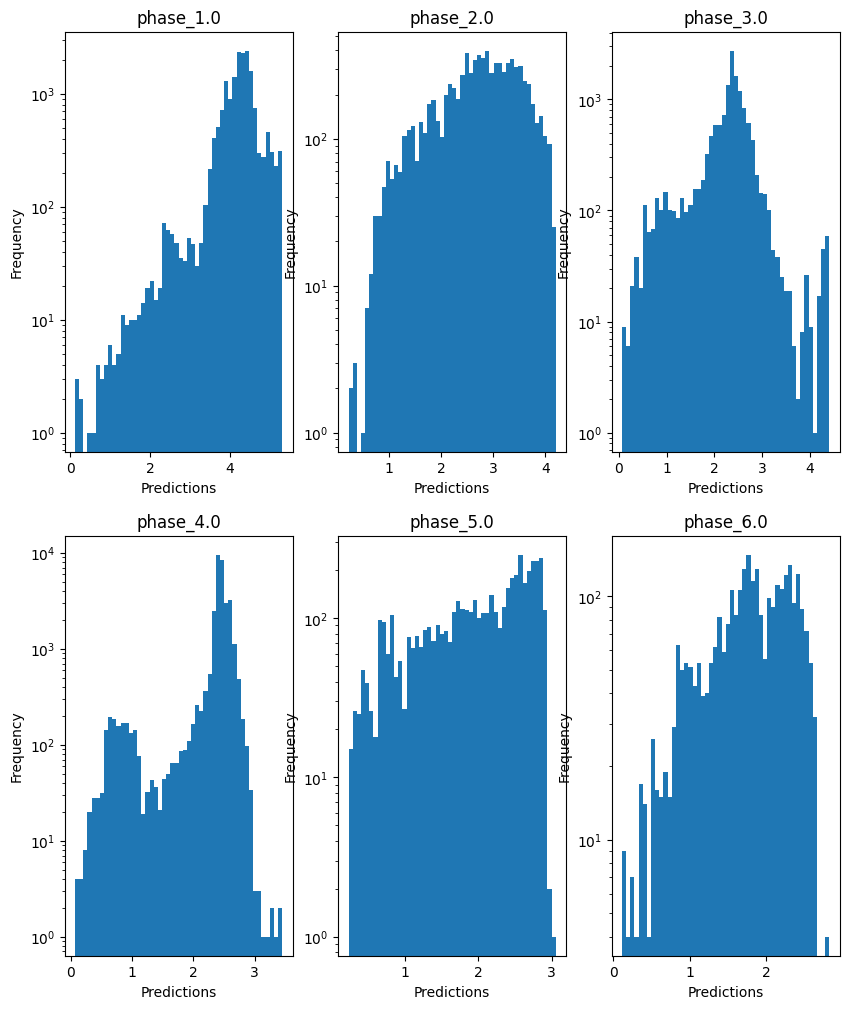

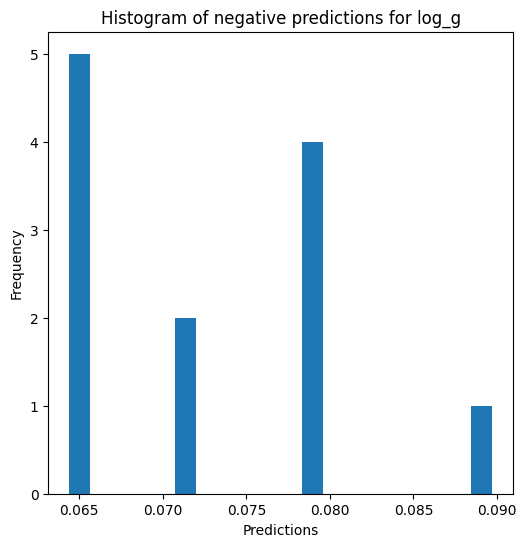


radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.7942482758349516
  RMSE :  0.17452412033938236
  MAE :  0.05411627306223335
  MedAE :  0.005685835755404572
  CORR :  0.9147917039173825
  MAX_ER :  1.7332127948462461
  Percentiles : 
    75th percentile :  0.018862527626662906
    90th percentile :  0.18698412593243927
    95th percentile :  0.2223370252445428
    99th percentile :  0.9612011017458798

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.8083849973353154
  RMSE :  0.28244383513703714
  MAE :  0.1654104393460247
  MedAE :  0.06740675770224425
  CORR :  0.8991682953509462
  MAX_ER :  1.6017493869408512
  Percentiles : 
    75th percentile :  0.17845443659863403
    90th percentile :  0.514447391475768
    95th percentile :  0.6593510480707294
    99th percentile :  0.9989356315892578

radius results for the phase category w

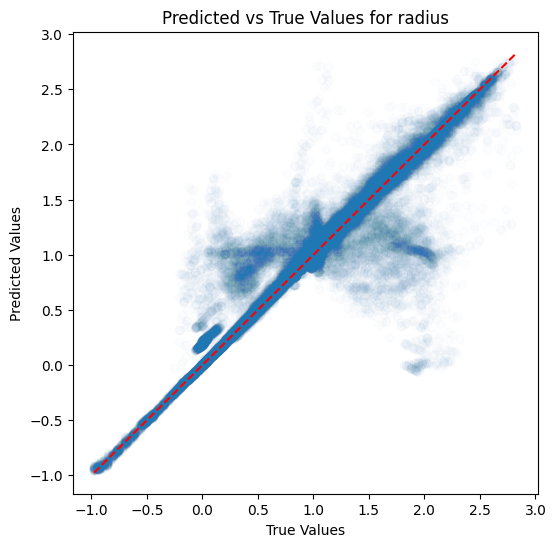

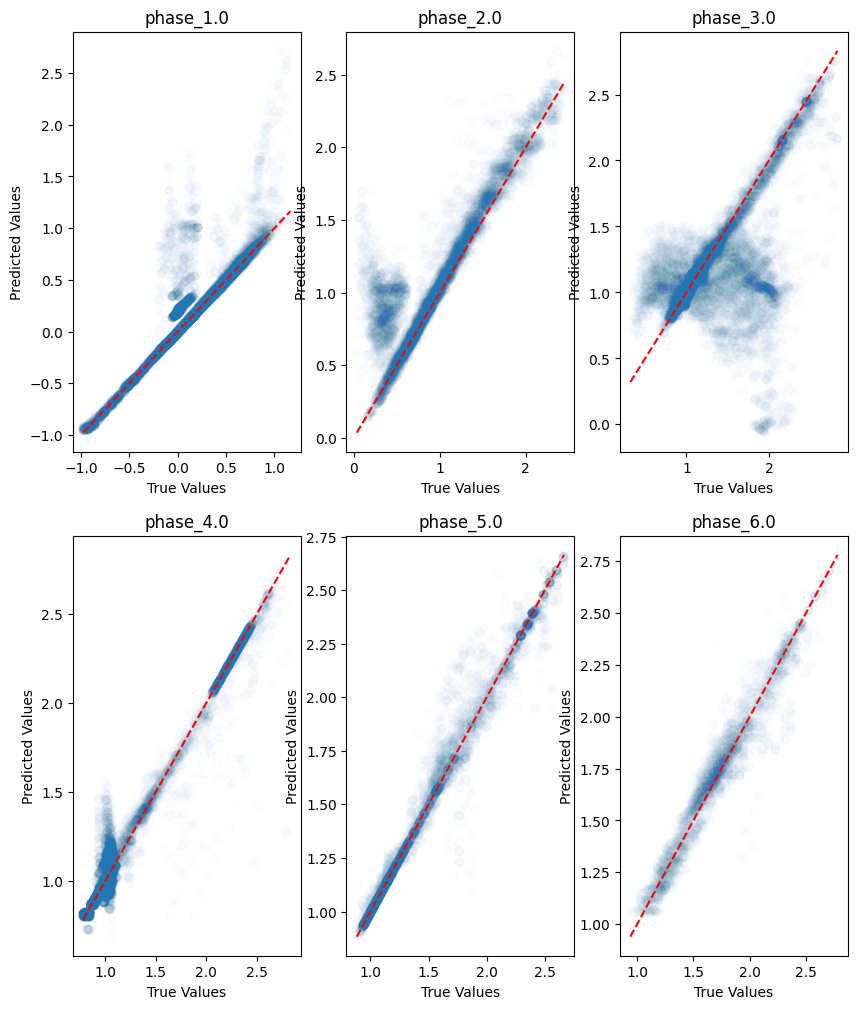

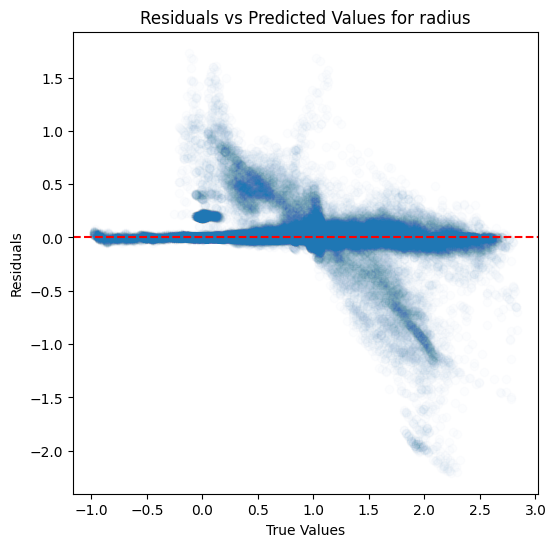

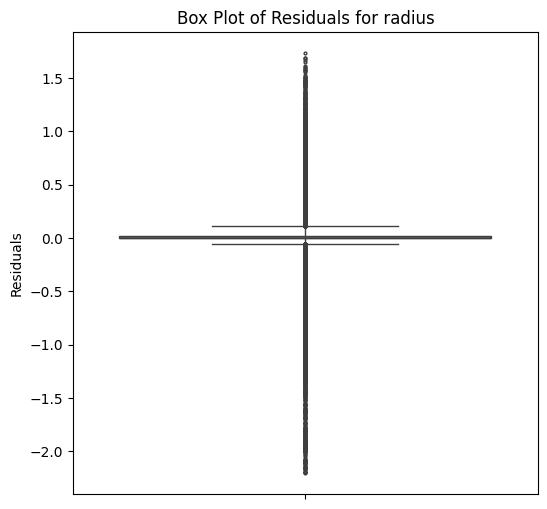

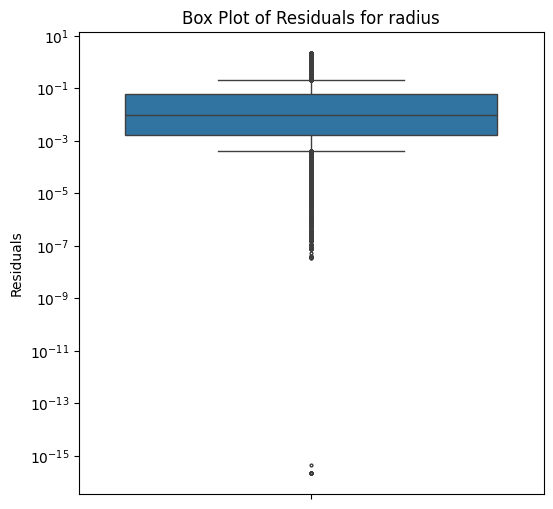

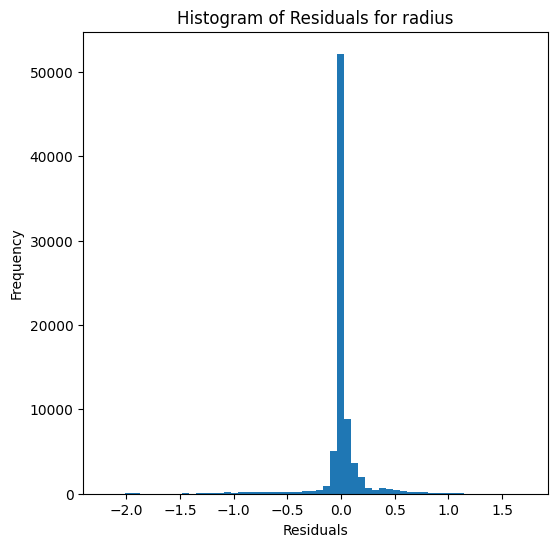

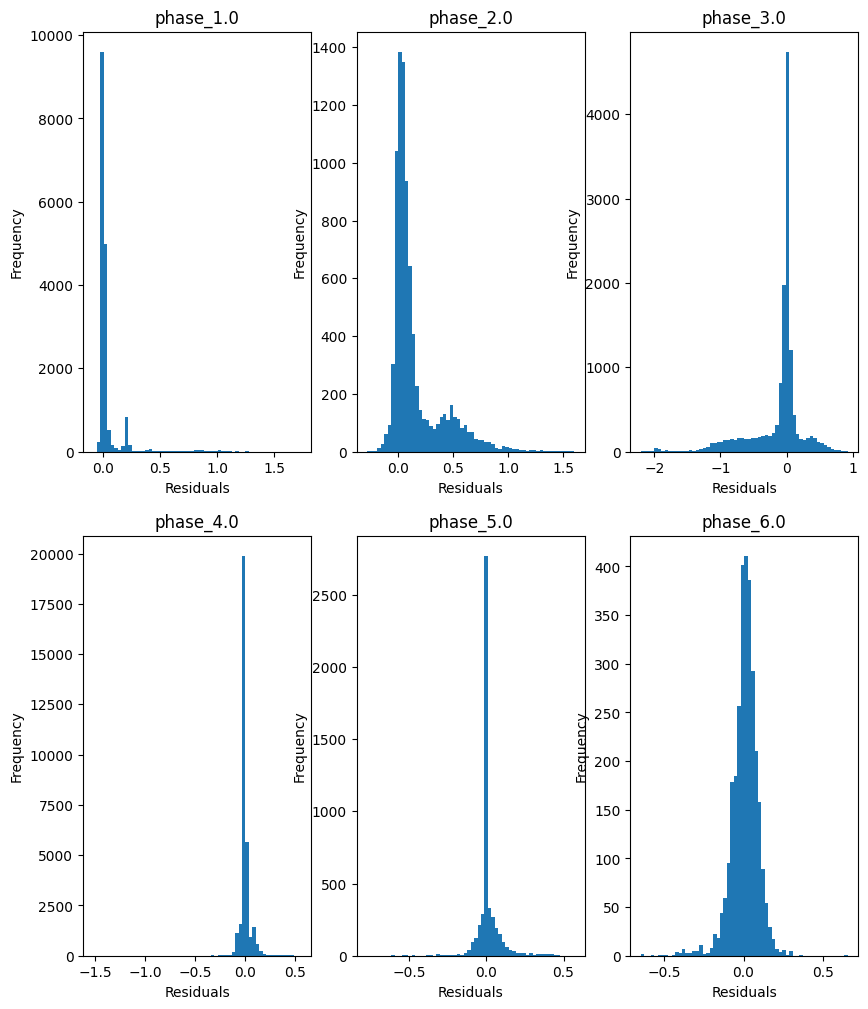

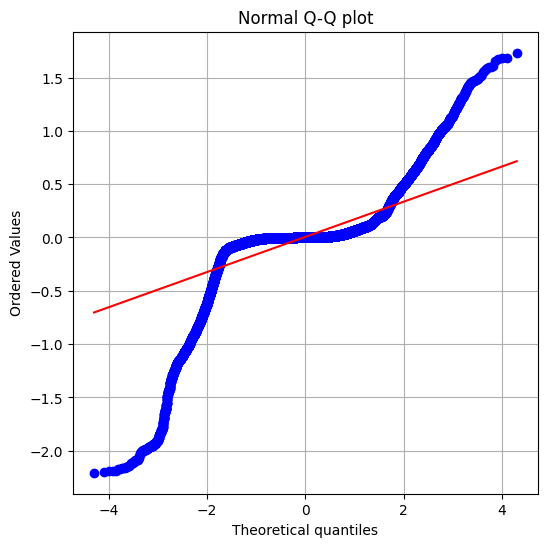

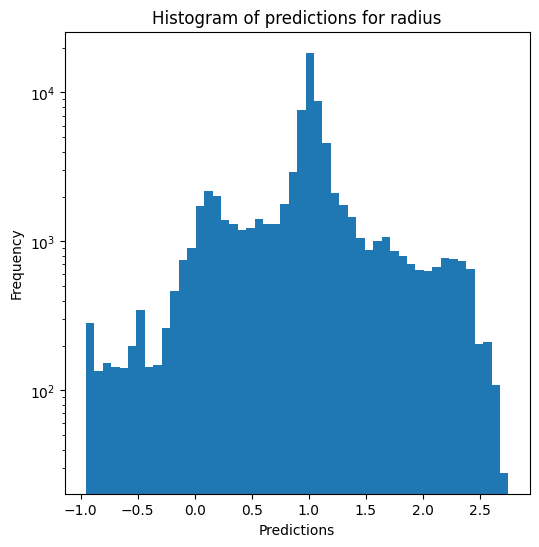

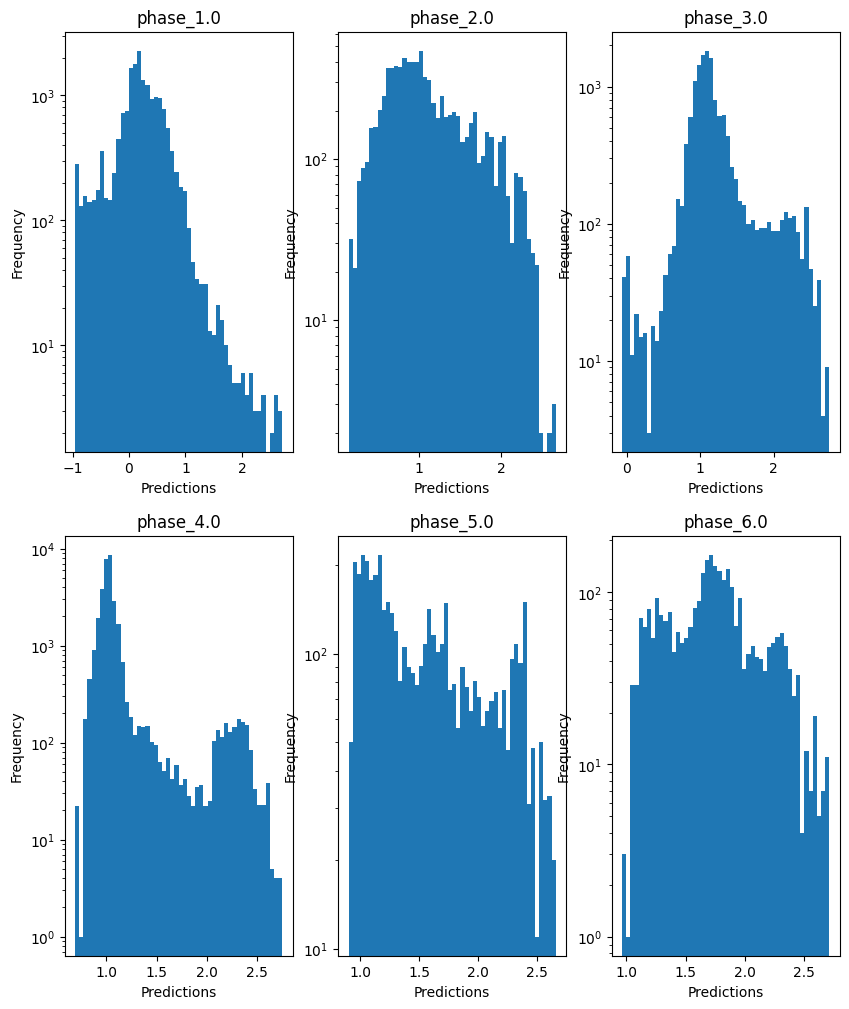

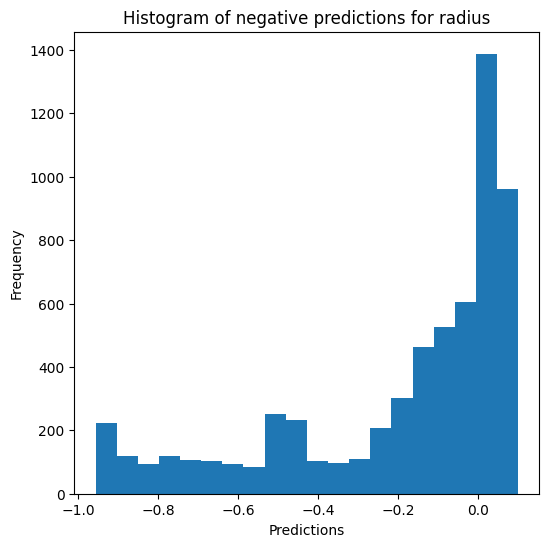

Saving predictions and results...


In [14]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 75, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_power, X_ivs_power, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_KNN)

## Decision tree

In [15]:
tag = "scale_power"

../../../../../../results/model_B/final_models/

scale_power train data :
Training the model...
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.9768870827656194
  RMSE :  0.04109279989676681
  MAE :  0.009689301172880634
  MedAE :  0.000688888888888739
  CORR :  0.9885540031244476
  MAX_ER :  0.8056800000000006
  Percentiles : 
    75th percentile :  0.005537500000000417
    90th percentile :  0.0197492857142858
    95th percentile :  0.03909099999999969
    99th percentile :  0.13068500000000172

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.9022043863534797
  RMSE :  0.054212282450538975
  MAE :  0.03395963077506845
  MedAE :  0.01915606060606012
  CORR :  0.9547755826248541
  MAX_ER :  0.5610421052631582
  Percentiles : 
    75th percentile :  0.046844642857143404
    90th percentile :  0.08326886363636325
    95th percentile :  0.1

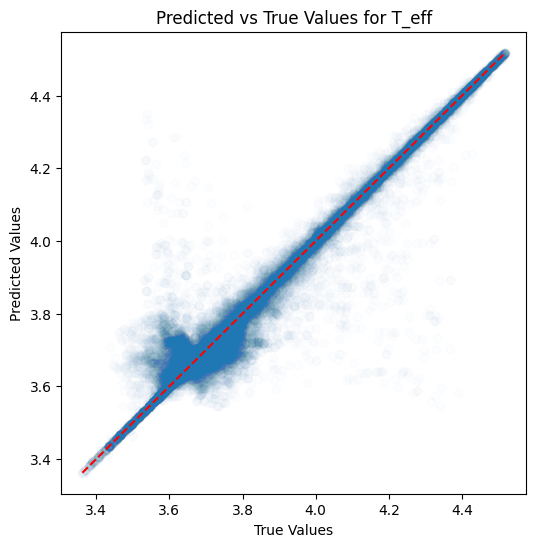

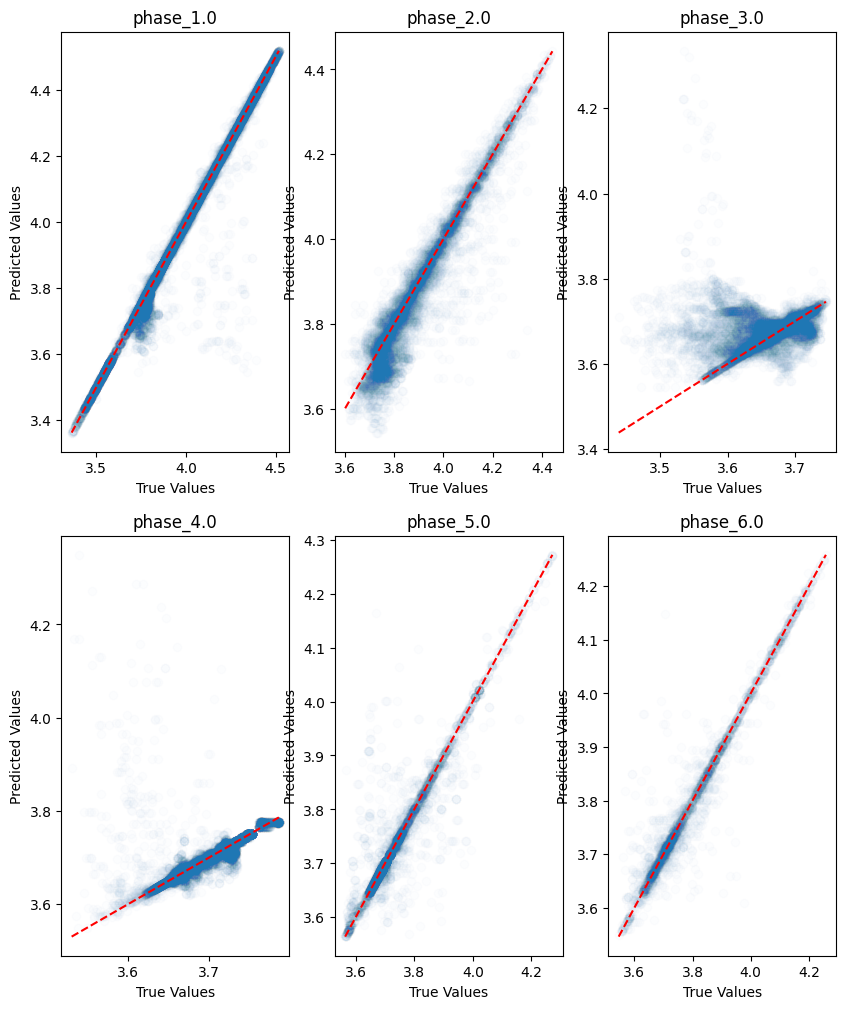

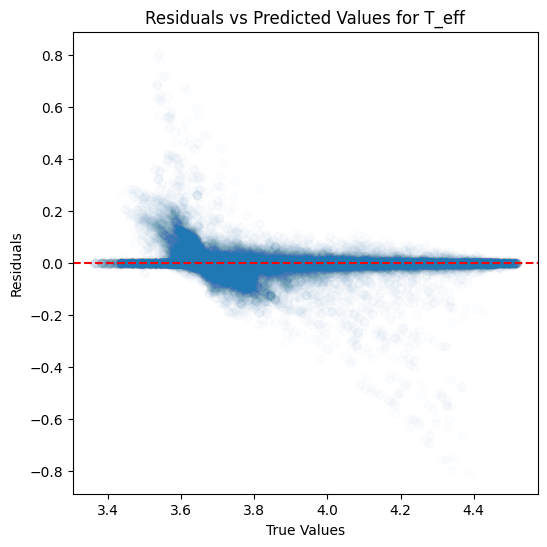

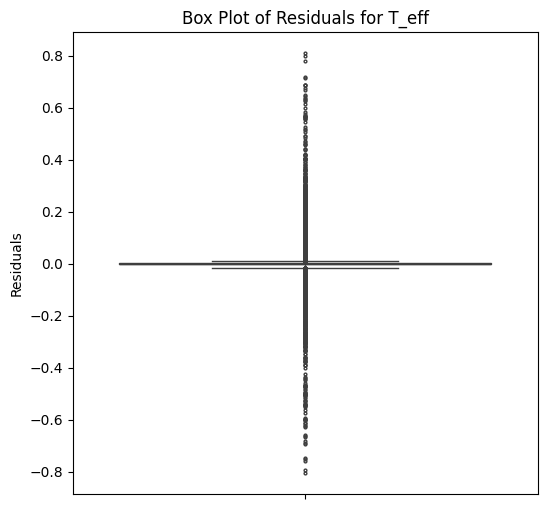

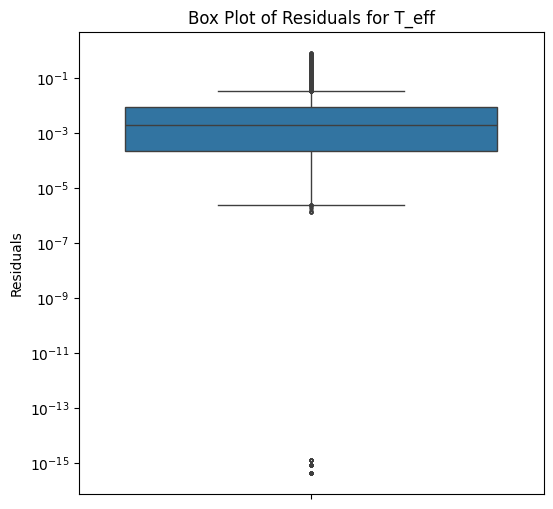

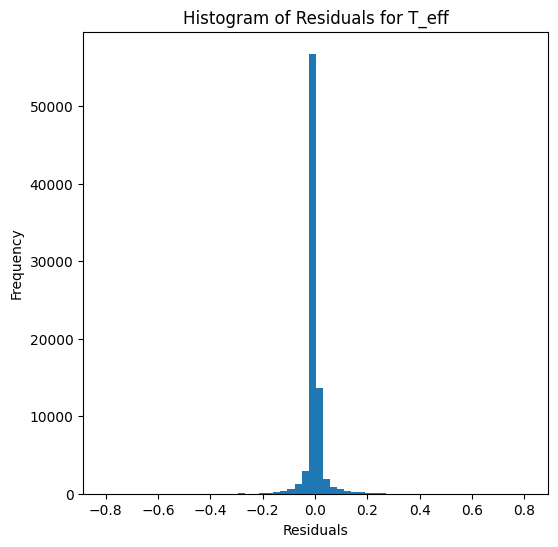

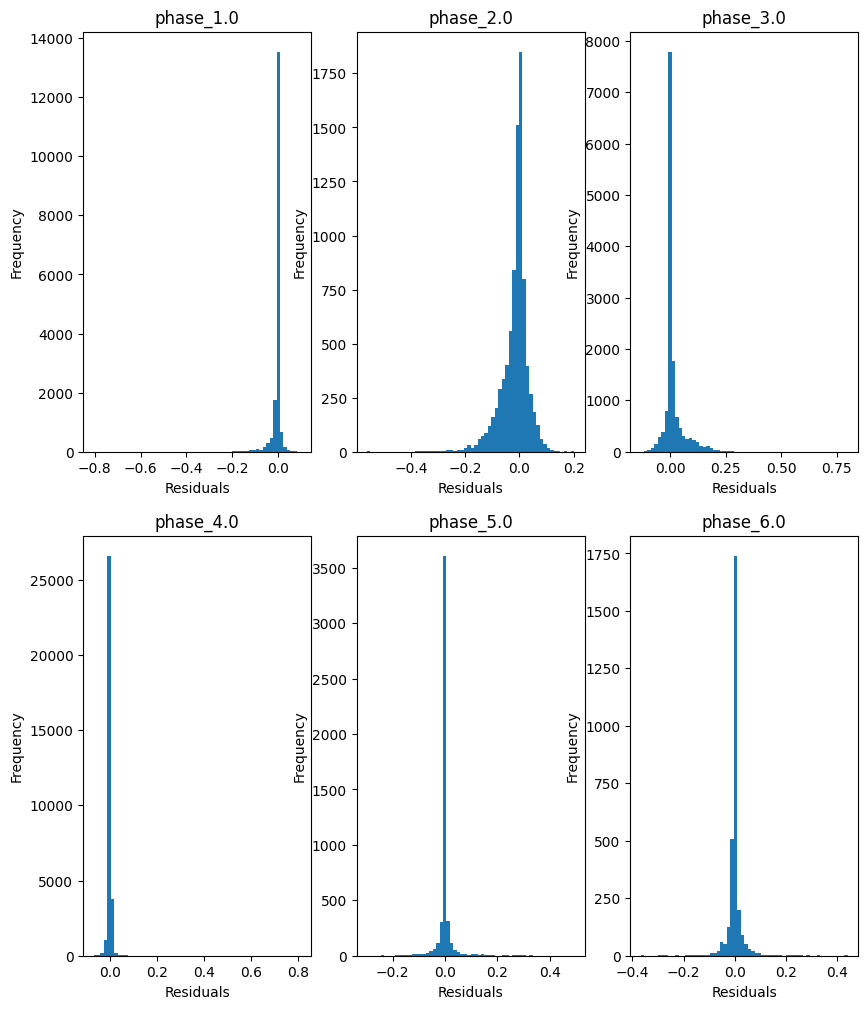

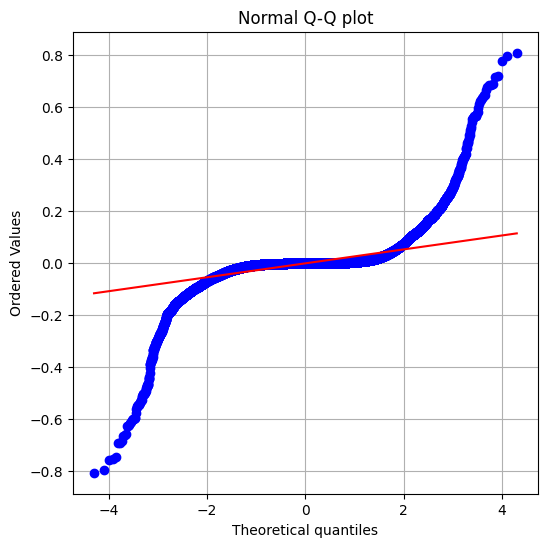

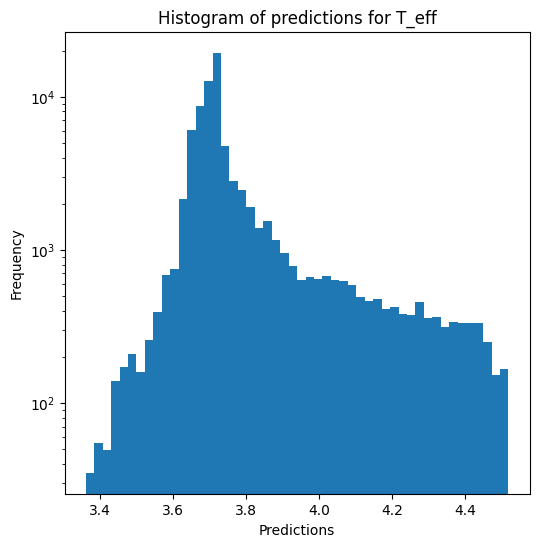

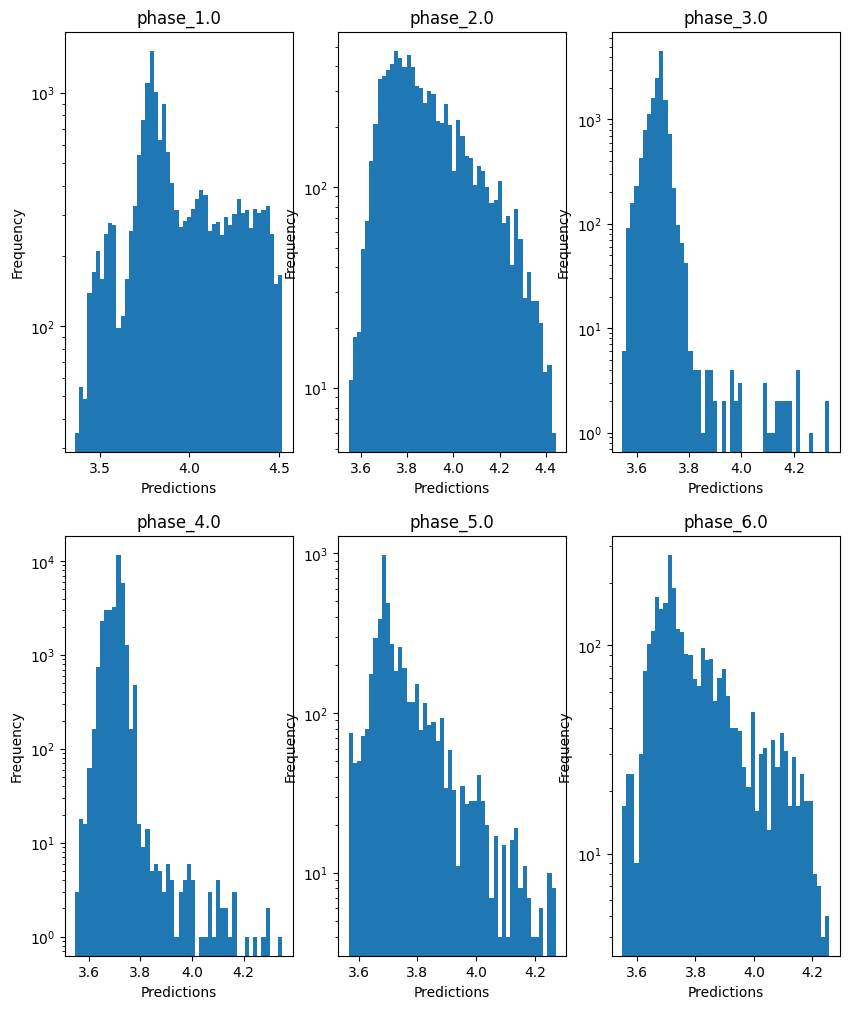


log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.1276844912296229
  RMSE :  0.32723730209462265
  MAE :  0.08213934363116714
  MedAE :  0.0034285714285715585
  CORR :  0.7690139185057048
  MAX_ER :  4.18
  Percentiles : 
    75th percentile :  0.016000000000000902
    90th percentile :  0.0706625000000002
    95th percentile :  0.5608571428571436
    99th percentile :  1.8373557665904017

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.593369143299931
  RMSE :  0.5523982734362031
  MAE :  0.274578158335633
  MedAE :  0.07457142857142784
  CORR :  0.7963358159526809
  MAX_ER :  3.2471111111111117
  Percentiles : 
    75th percentile :  0.228637987012987
    90th percentile :  1.0253403846153846
    95th percentile :  1.402671122994652
    99th percentile :  2.114641999999999

log_g results for the phase category with a value of 3.0
  value range :  -0.347 - 3.787
  RVE :  -0.01668824656

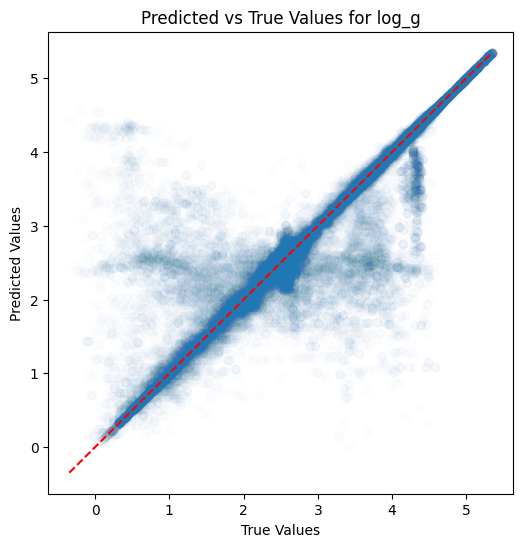

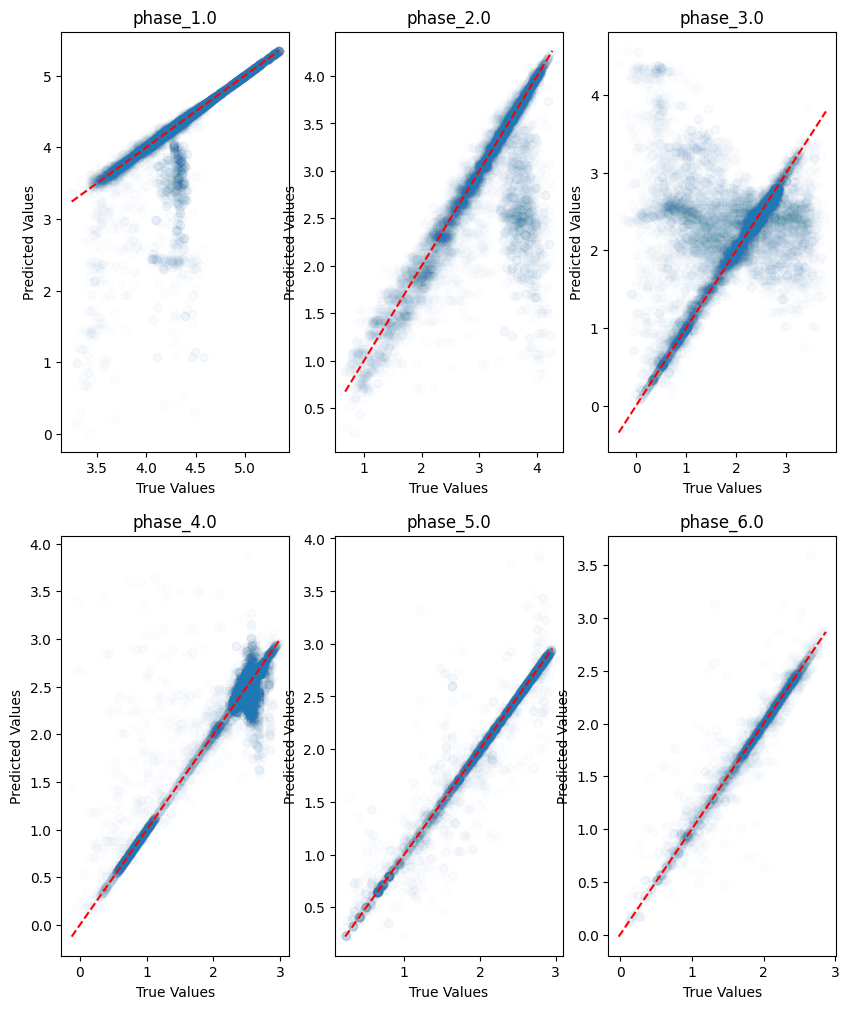

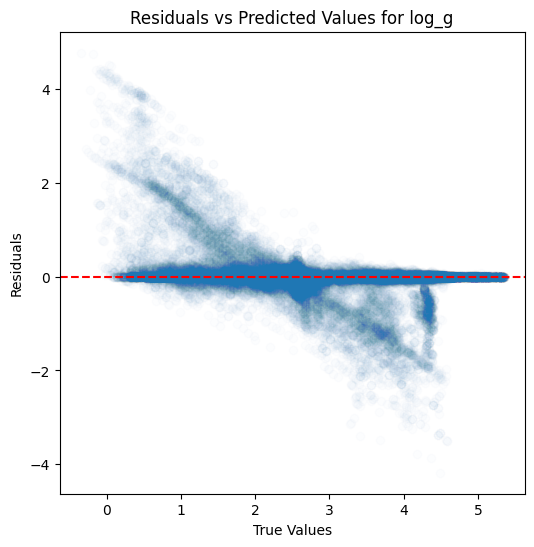

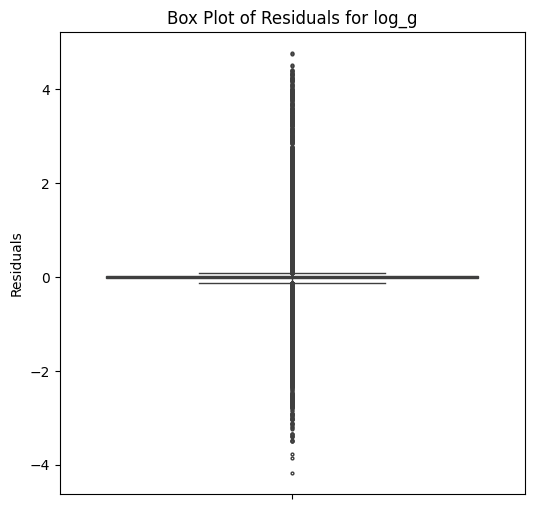

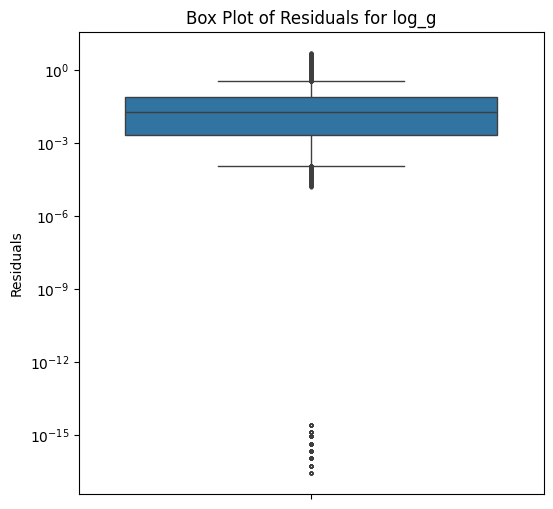

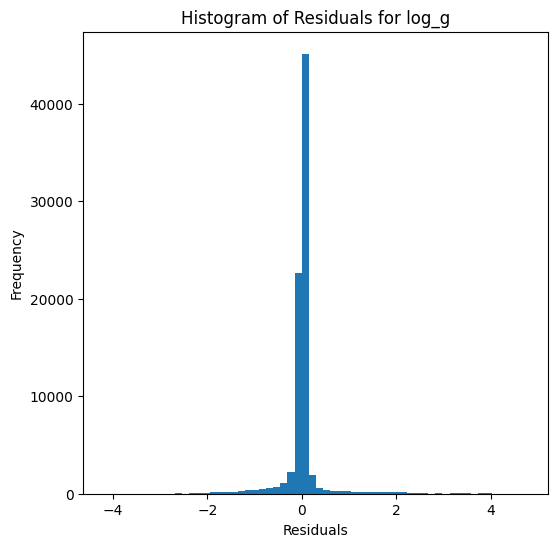

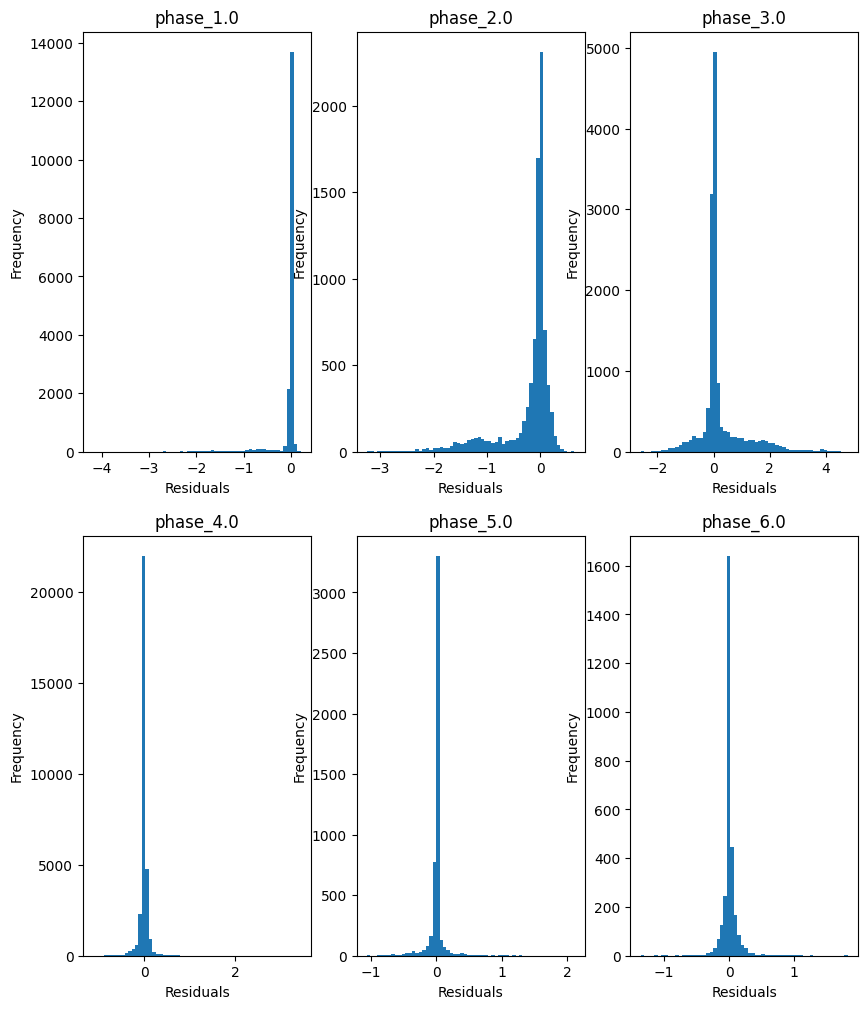

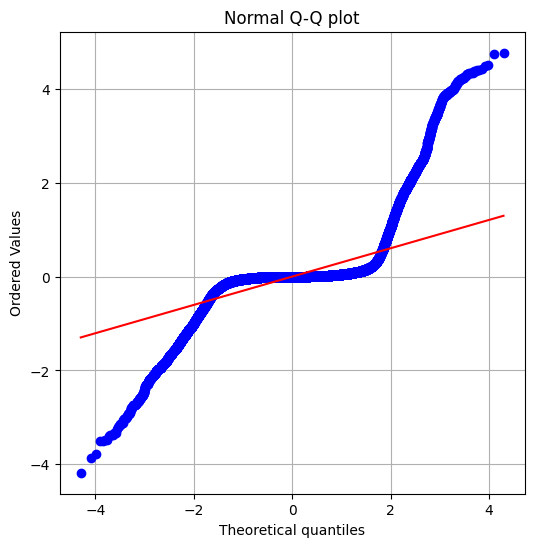

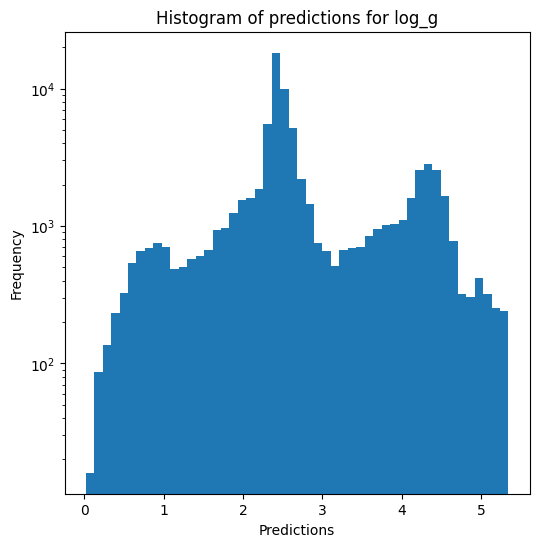

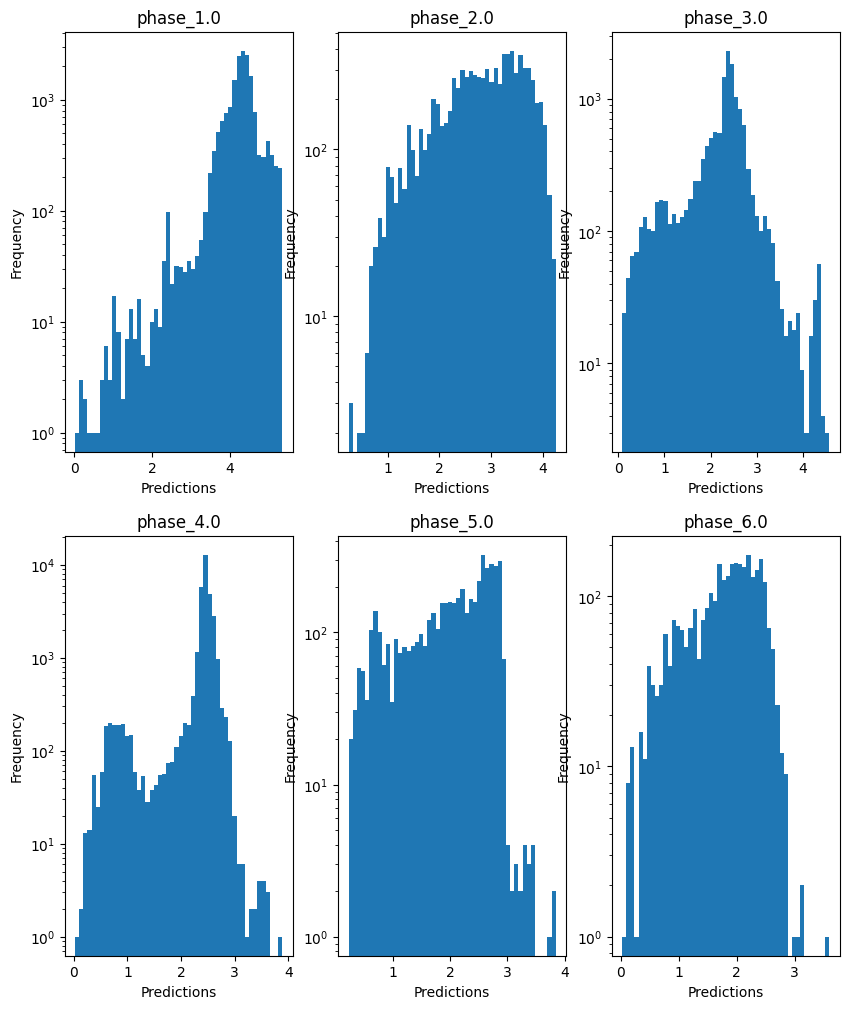

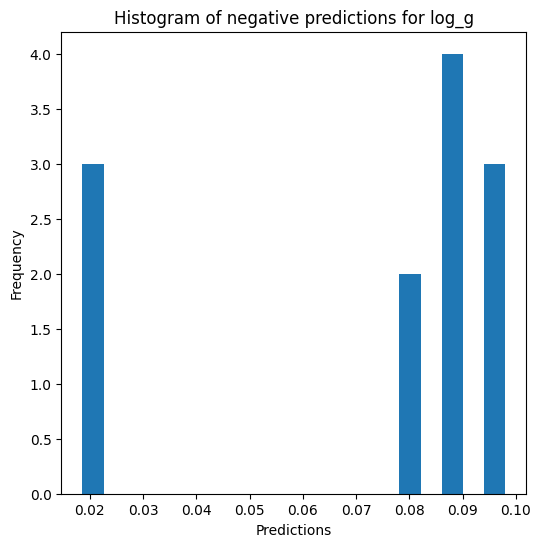


radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.8105430574262739
  RMSE :  0.16439585924693967
  MAE :  0.042541235974701164
  MedAE :  0.0021863387483283536
  CORR :  0.9186309481829671
  MAX_ER :  2.090872933956464
  Percentiles : 
    75th percentile :  0.010612904536124334
    90th percentile :  0.04368489814915023
    95th percentile :  0.2807032027034853
    99th percentile :  0.9192326131187853

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.7784348434924497
  RMSE :  0.27621903158406325
  MAE :  0.13735189885112709
  MedAE :  0.03753010550708624
  CORR :  0.8835189283779687
  MAX_ER :  1.6219379657090227
  Percentiles : 
    75th percentile :  0.11421580577057108
    90th percentile :  0.5125249453715149
    95th percentile :  0.701388214366825
    99th percentile :  1.057853078351966

radius results for the phase category 

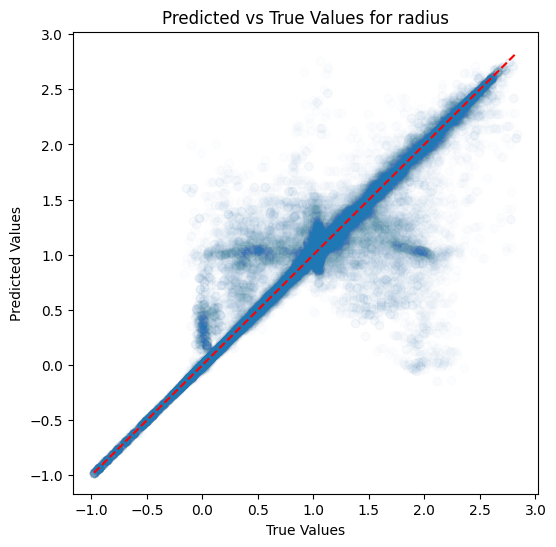

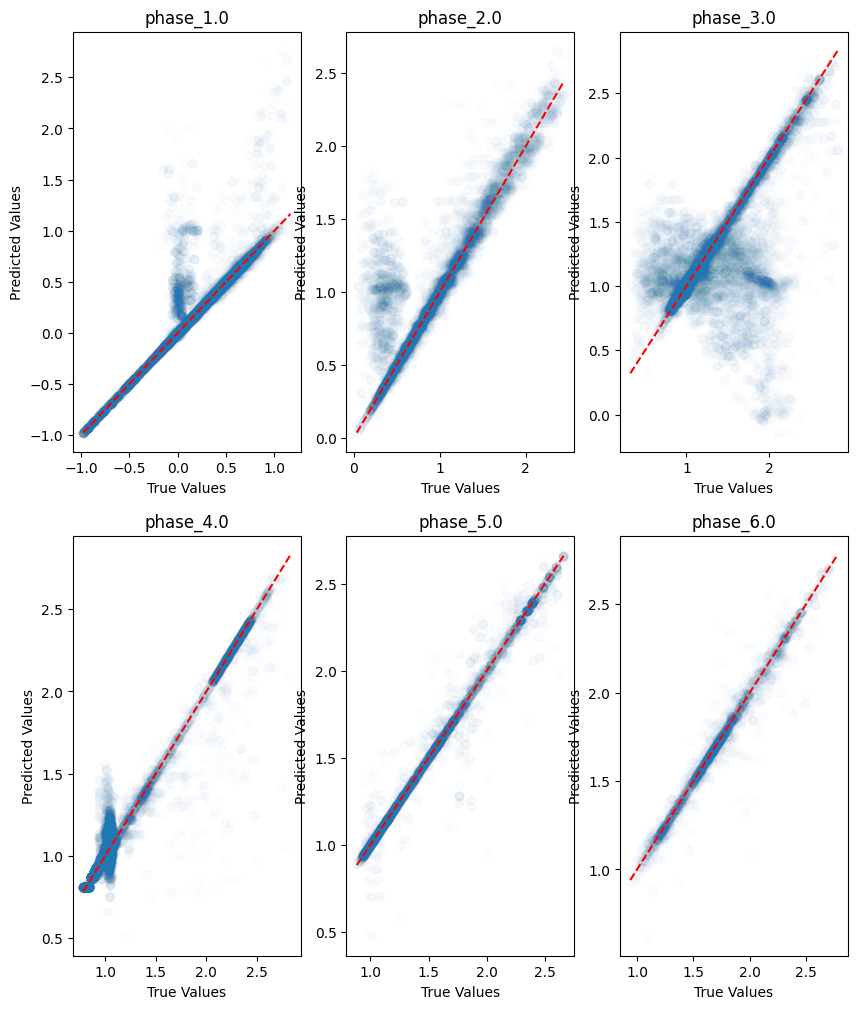

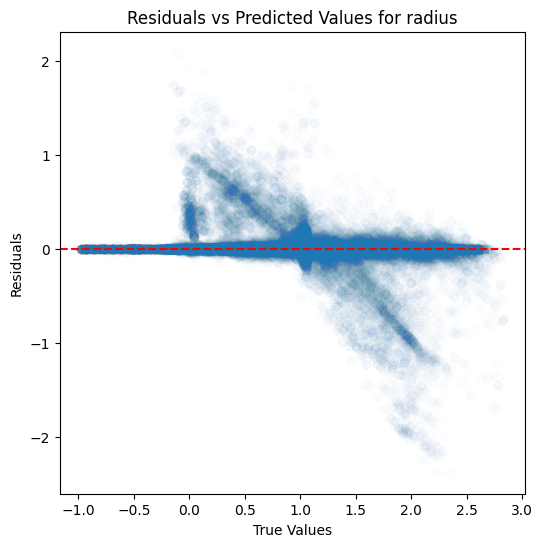

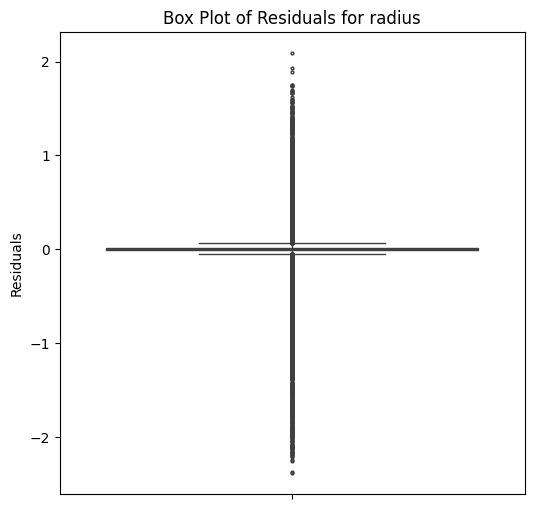

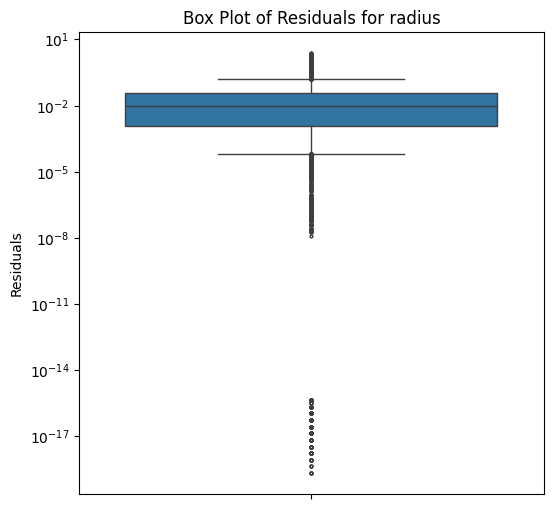

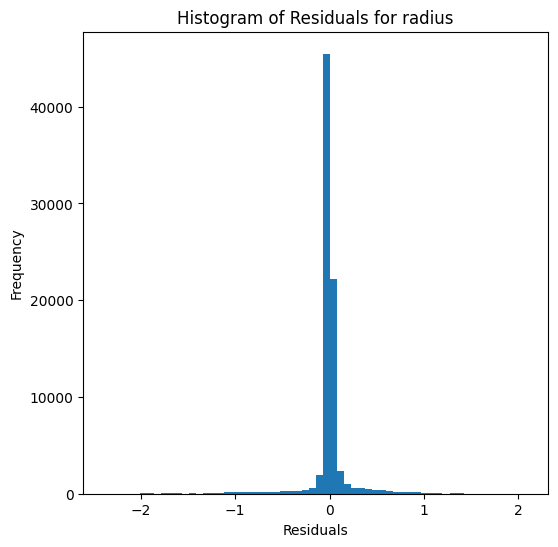

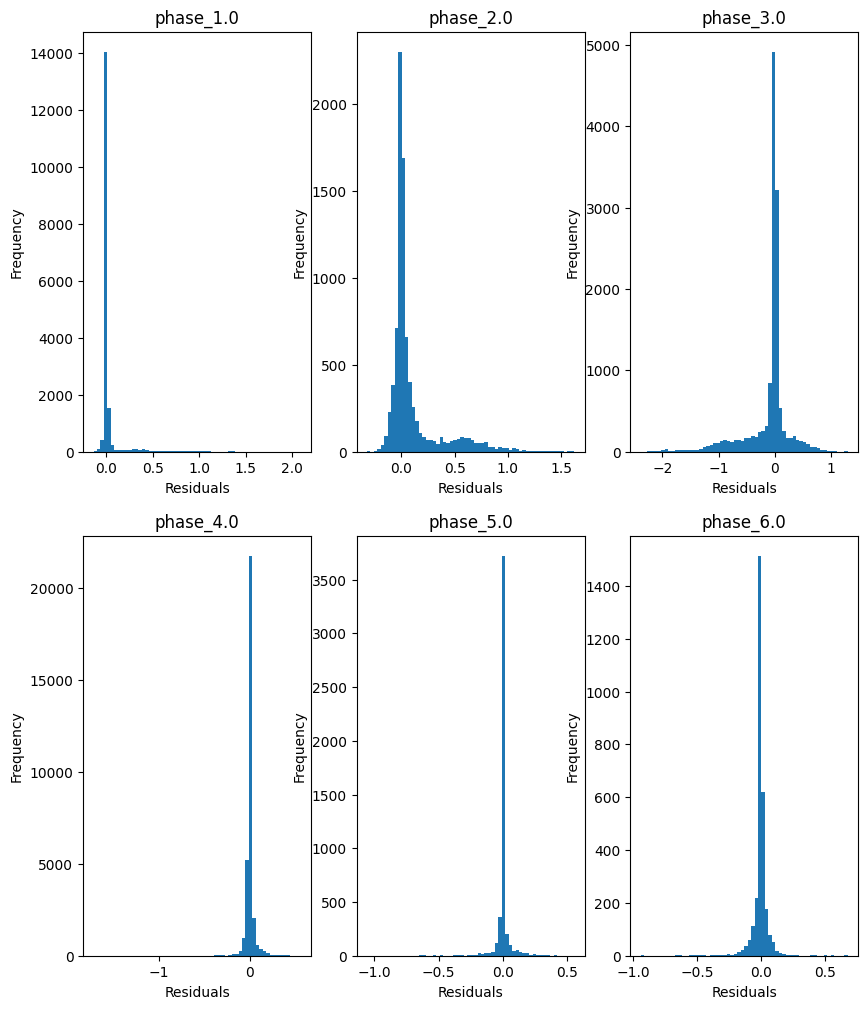

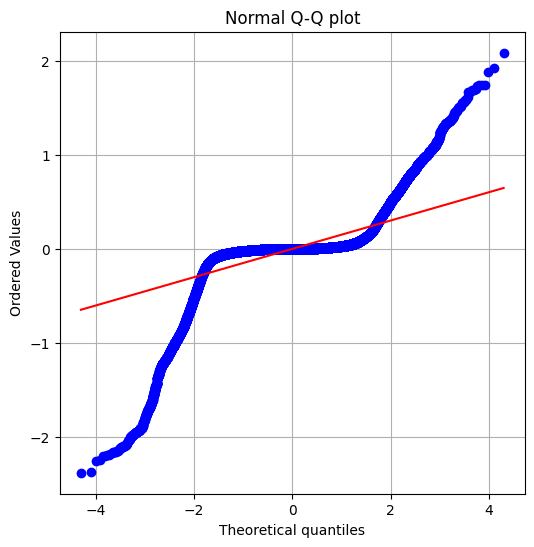

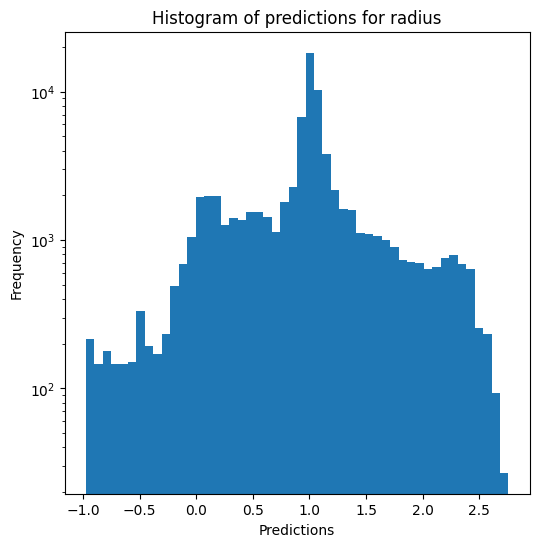

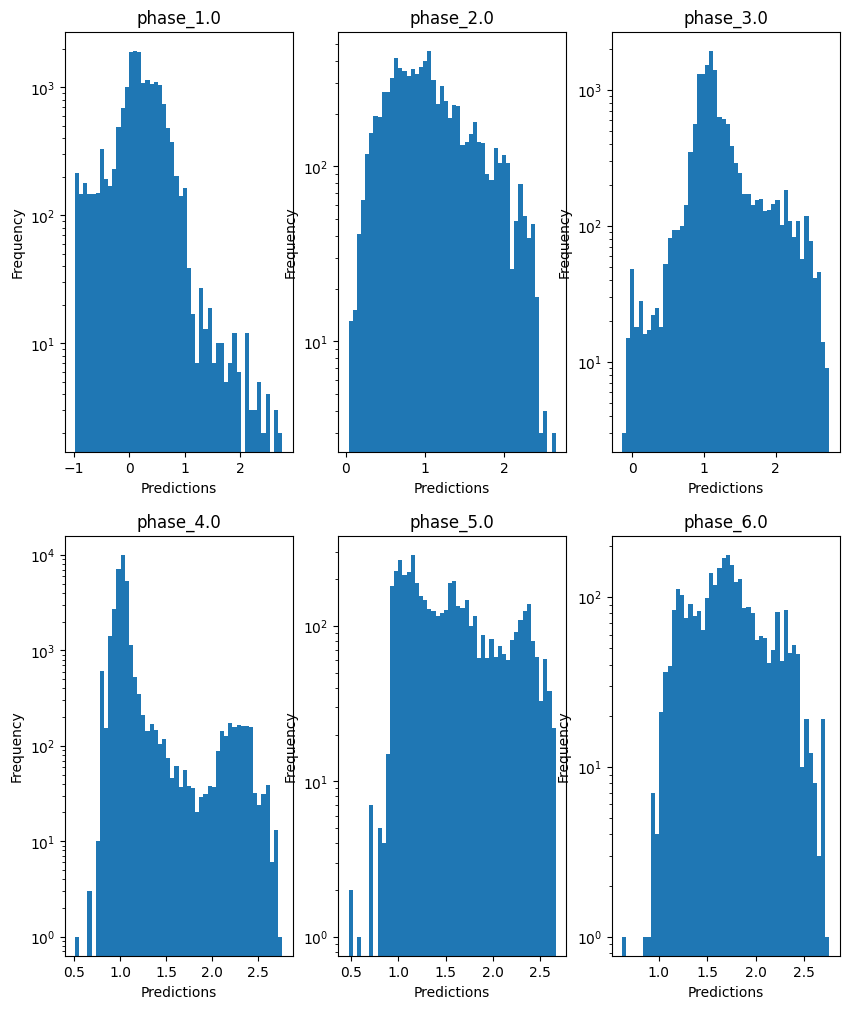

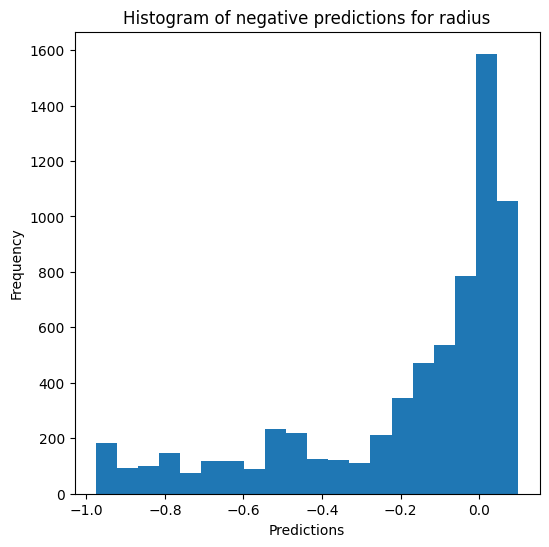

Saving predictions and results...


In [16]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 5, 'min_samples_split': 4, 'max_features': None, 'max_leaf_nodes': None}

print(path_to_results)
evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(DecisionTreeRegressor, X_train_power, X_ivs_power, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_DT)

# Training the final models

In [9]:
X = np.append(X_train, X_ivs, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
X_power = np.append(X_train_power, X_ivs_power, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_quantile.shape)
print(X_power.shape)
print(y.shape)

(321696, 3)
(321696, 3)
(321696, 3)
(321696, 3)


## Random forest

In [18]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 3, 'min_samples_split': 10, 'max_features': None, 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X_quantile, y)

,n_estimators,300
,criterion,'friedman_mse'
,max_depth,50
,min_samples_split,10
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 500 MB
# 22.2 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/RF_compress_3.pkl']

## KNN

In [10]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 75, 'n_neighbors': 10, 'weights': 'uniform'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_power, y)

,n_neighbors,10
,weights,'uniform'
,algorithm,'ball_tree'
,leaf_size,75
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 25 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/KNN_compress_0.pkl']

## Decision tree

In [12]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 5, 'min_samples_split': 4, 'max_features': None, 'max_leaf_nodes': None}

mdl = DecisionTreeRegressor(**best_params_DT)
mdl.fit(X_power, y)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,75
,min_samples_split,4
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "DT_compress_0.pkl", compress=0)
# 4.9 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/DT_compress_0.pkl']